In [1]:
from pathlib import Path
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import ExpPatternCompletionModel, BinaryPatternCompletionModel
from probcs.experiment_running.exc_experiment import center_surround_experiment, create_stimuli
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity
from probcs.utils.utils import select_focus_images, get_excitatory_images
from probcs.utils.plotting import plot_posterior

seed = 42
rng = np.random.default_rng(seed)

In [2]:
exc_images = get_excitatory_images()
vmin = exc_images.min()
vmax = exc_images.max()

In [3]:
exc_images.std(axis=0)

array([[0.39127862, 0.44075057, 0.50181717, ..., 0.35082639, 0.33117291,
        0.32332635],
       [0.47943543, 0.56134116, 0.6606333 , ..., 0.38266331, 0.35211174,
        0.33140351],
       [0.66690827, 0.80868344, 0.97616002, ..., 0.4732137 , 0.40524038,
        0.34776996],
       ...,
       [0.35573755, 0.37388579, 0.39719398, ..., 0.50961878, 0.47251698,
        0.44558015],
       [0.33029869, 0.35108561, 0.36445673, ..., 0.46365167, 0.44356833,
        0.41947418],
       [0.31190525, 0.32837292, 0.34451373, ..., 0.44124113, 0.4233128 ,
        0.38510607]])

In [4]:
# patterns = exc_images[[0, 1, 3, 8, 9]]
patterns = exc_images[:10]

In [5]:
G_dim = len(patterns)
G_prob = 0.5
I_sigma = 100
patterns_offset = 0

offset_x_1 = 0
offset_x_2 = 1
scale_x = 0.1
exponent_x = 3
zero_threshold_x = 0.00
g_x_mapping = None

G_visual_nrows = G_dim
G_visual_ncols = 1
x_visual_nrows = G_dim
x_visual_ncols = 9
n_tune = 2000
n_draws = 2000
n_chains = 4
n_cores = 4

In [6]:
model = BinaryPatternCompletionModel(
    patterns=patterns,
    G_prob=G_prob,
    I_sigma=I_sigma,
    patterns_offset=patterns_offset,
    offset_x_1=offset_x_1,
    offset_x_2=offset_x_2,
    scale_x=scale_x,
    exponent_x=exponent_x,
    zero_threshold_x=zero_threshold_x,
    g_x_mapping=g_x_mapping
)

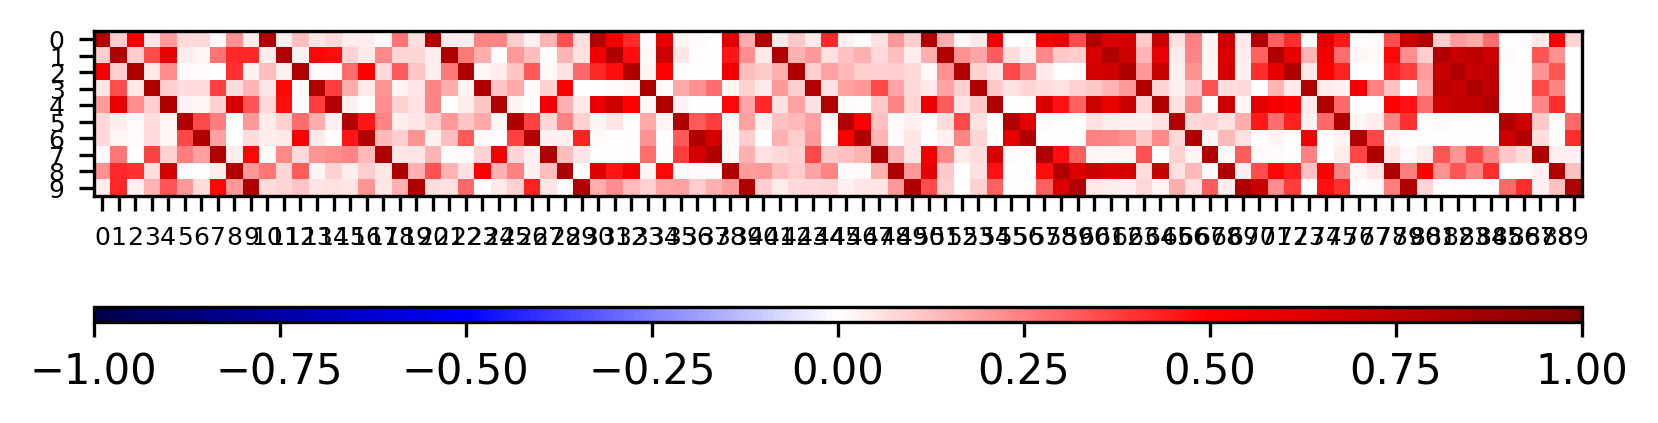

In [7]:
fig, ax = plt.subplots(dpi=300)
ax.imshow(model.G_X_mapping.T, cmap="seismic", vmin=-1, vmax=1)
ax.set_xticks(np.arange(G_dim*9))
ax.set_xticklabels(np.arange(G_dim*9))
ax.set_yticks(np.arange(G_dim))
ax.set_yticklabels(np.arange(G_dim))
ax.tick_params(axis='both', which='major', labelsize=6)
# draw a small horizontal colorbar
cbar = fig.colorbar(ax.get_images()[0], ax=ax, orientation="horizontal", pad=0.1, aspect=100)

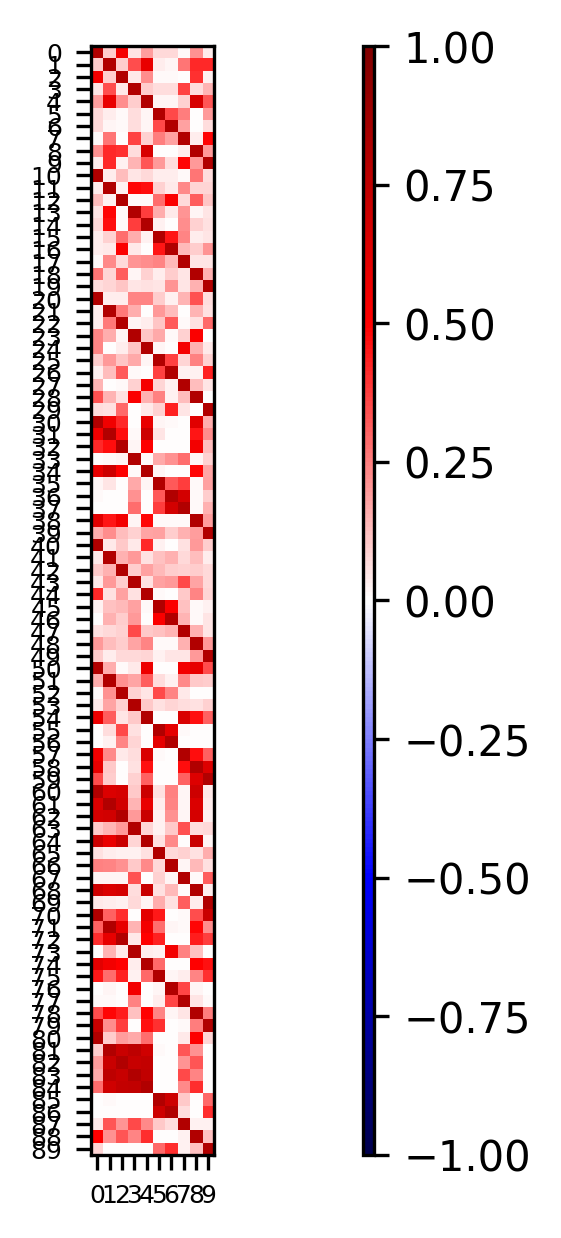

In [8]:
fig, ax = plt.subplots(dpi=300)
ax.imshow(model.G_X_mapping, cmap="seismic", vmin=-1, vmax=1)
ax.set_xticks(np.arange(G_dim))
ax.set_xticklabels(np.arange(G_dim))
ax.set_yticks(np.arange(G_dim*9))
ax.set_yticklabels(np.arange(G_dim*9))
ax.tick_params(axis='both', which='major', labelsize=6)
# draw a small horizontal colorbar
cbar = fig.colorbar(ax.get_images()[0], ax=ax, orientation="vertical", pad=0.1, aspect=100)

In [9]:
mapping = np.zeros((G_dim*9, G_dim)) + 0.05

In [10]:
for j in range(0, G_dim*9, G_dim):
    for i in range(G_dim):
        mapping[i + j, i] = 0.8

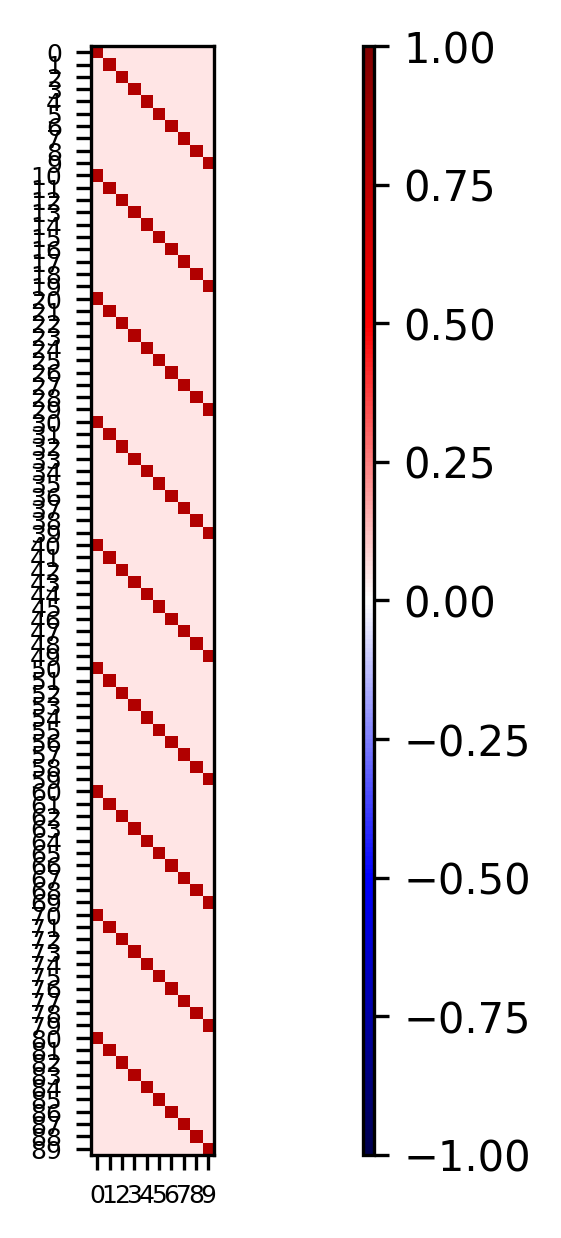

In [11]:
fig, ax = plt.subplots(dpi=300)
ax.imshow(mapping, cmap="seismic", vmin=-1, vmax=1)
ax.set_xticks(np.arange(G_dim))
ax.set_xticklabels(np.arange(G_dim))
ax.set_yticks(np.arange(G_dim*9))
ax.set_yticklabels(np.arange(G_dim*9))
ax.tick_params(axis='both', which='major', labelsize=6)
# draw a small horizontal colorbar
cbar = fig.colorbar(ax.get_images()[0], ax=ax, orientation="vertical", pad=0.1, aspect=100)

In [12]:
model = BinaryPatternCompletionModel(
    patterns=patterns,
    G_prob=G_prob,
    I_sigma=I_sigma,
    patterns_offset=patterns_offset,
    offset_x_1=offset_x_1,
    offset_x_2=offset_x_2,
    scale_x=scale_x,
    exponent_x=exponent_x,
    zero_threshold_x=zero_threshold_x,
    g_x_mapping=mapping
)

In [13]:
cossim = cosine_similarity(model.patterns.reshape(model.patterns.shape[0], -1))

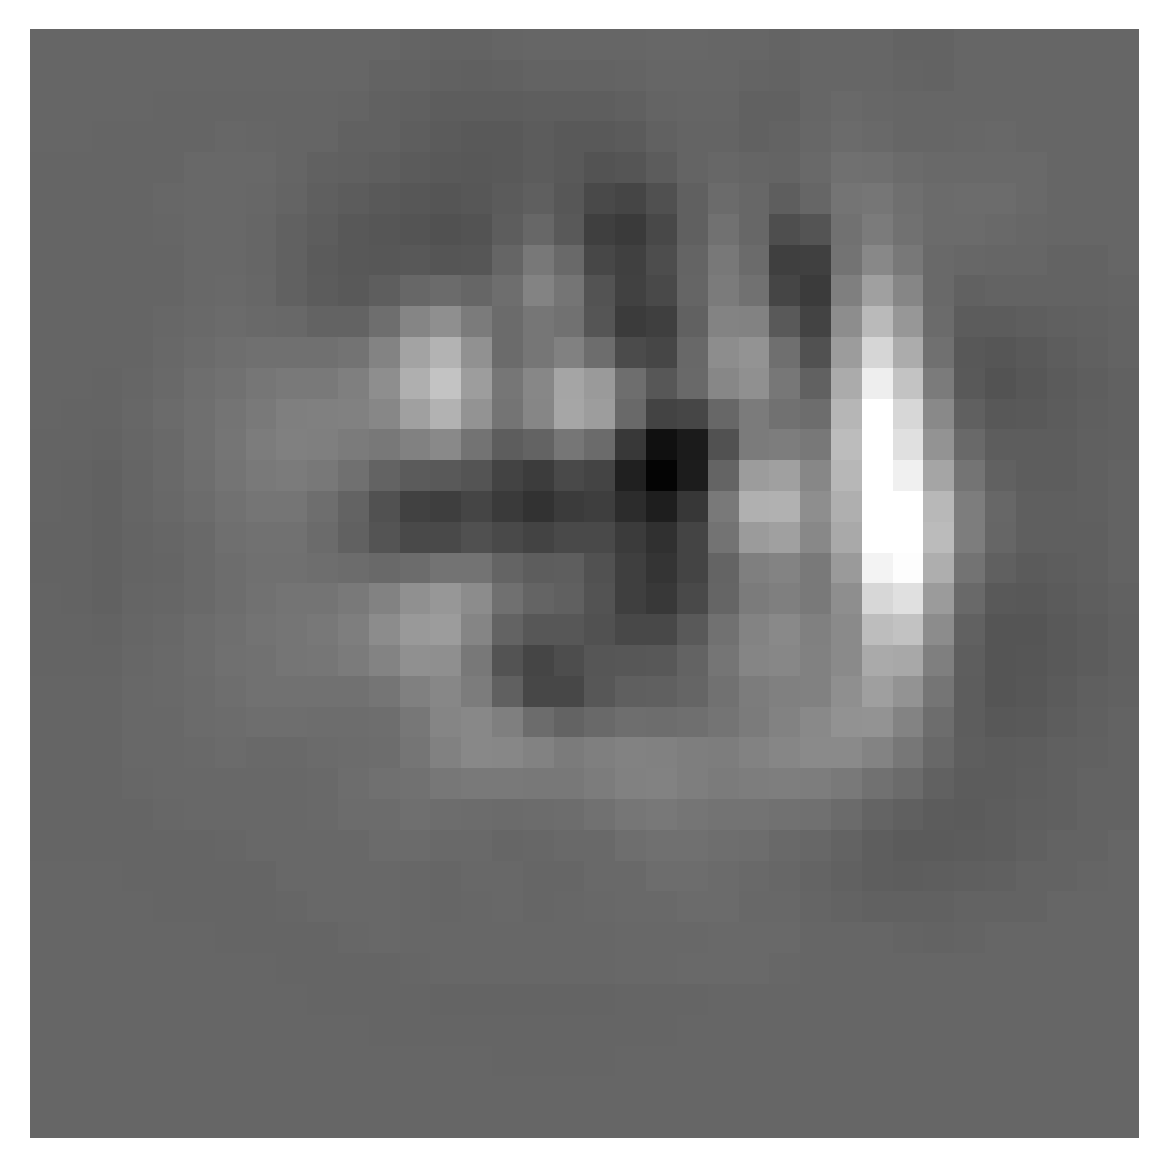

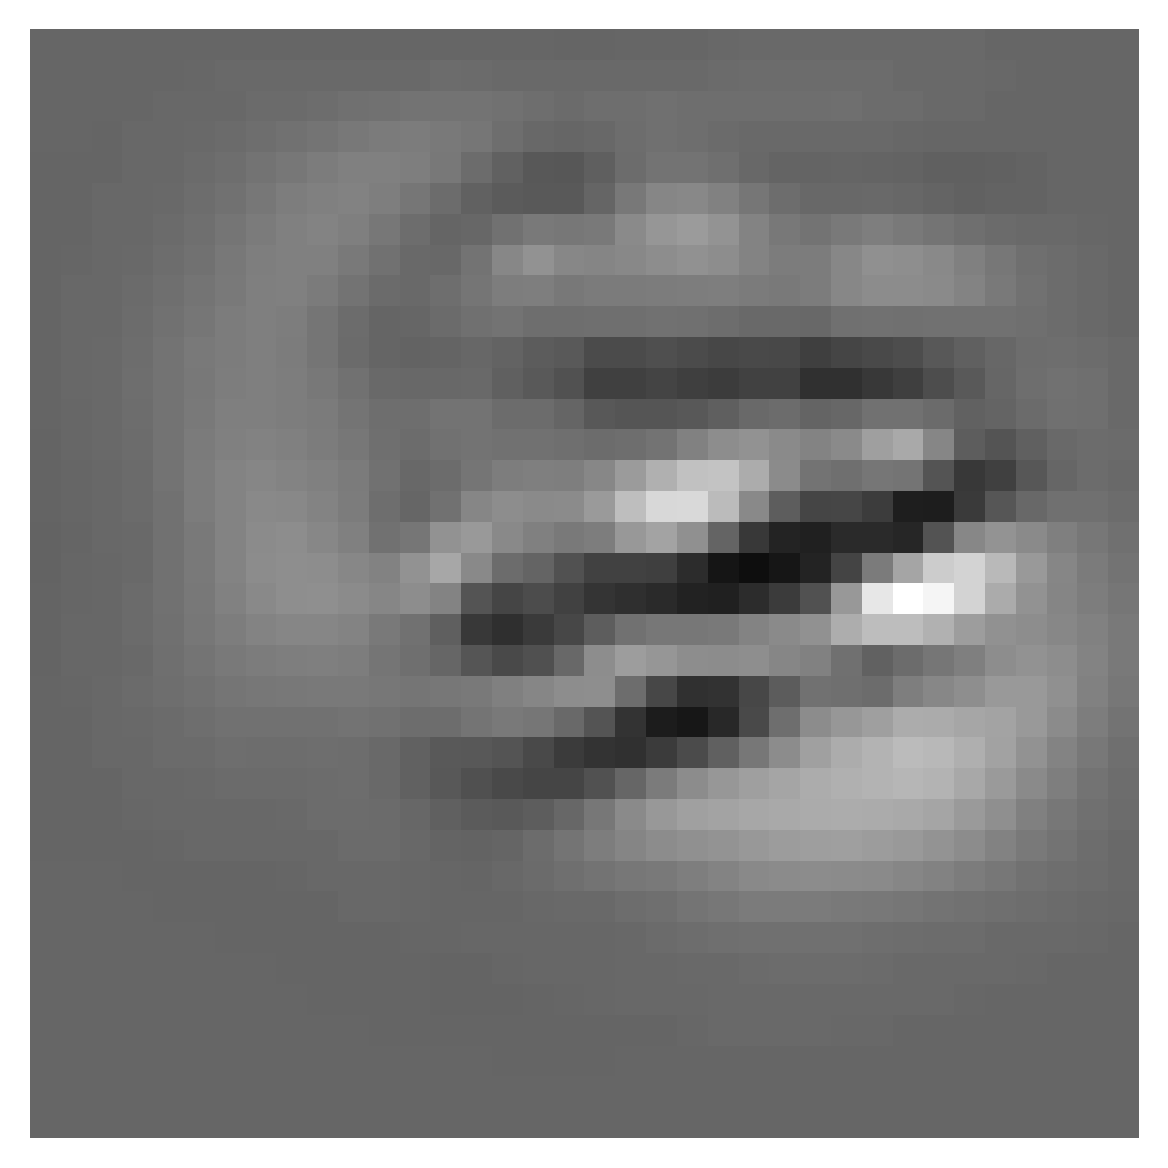

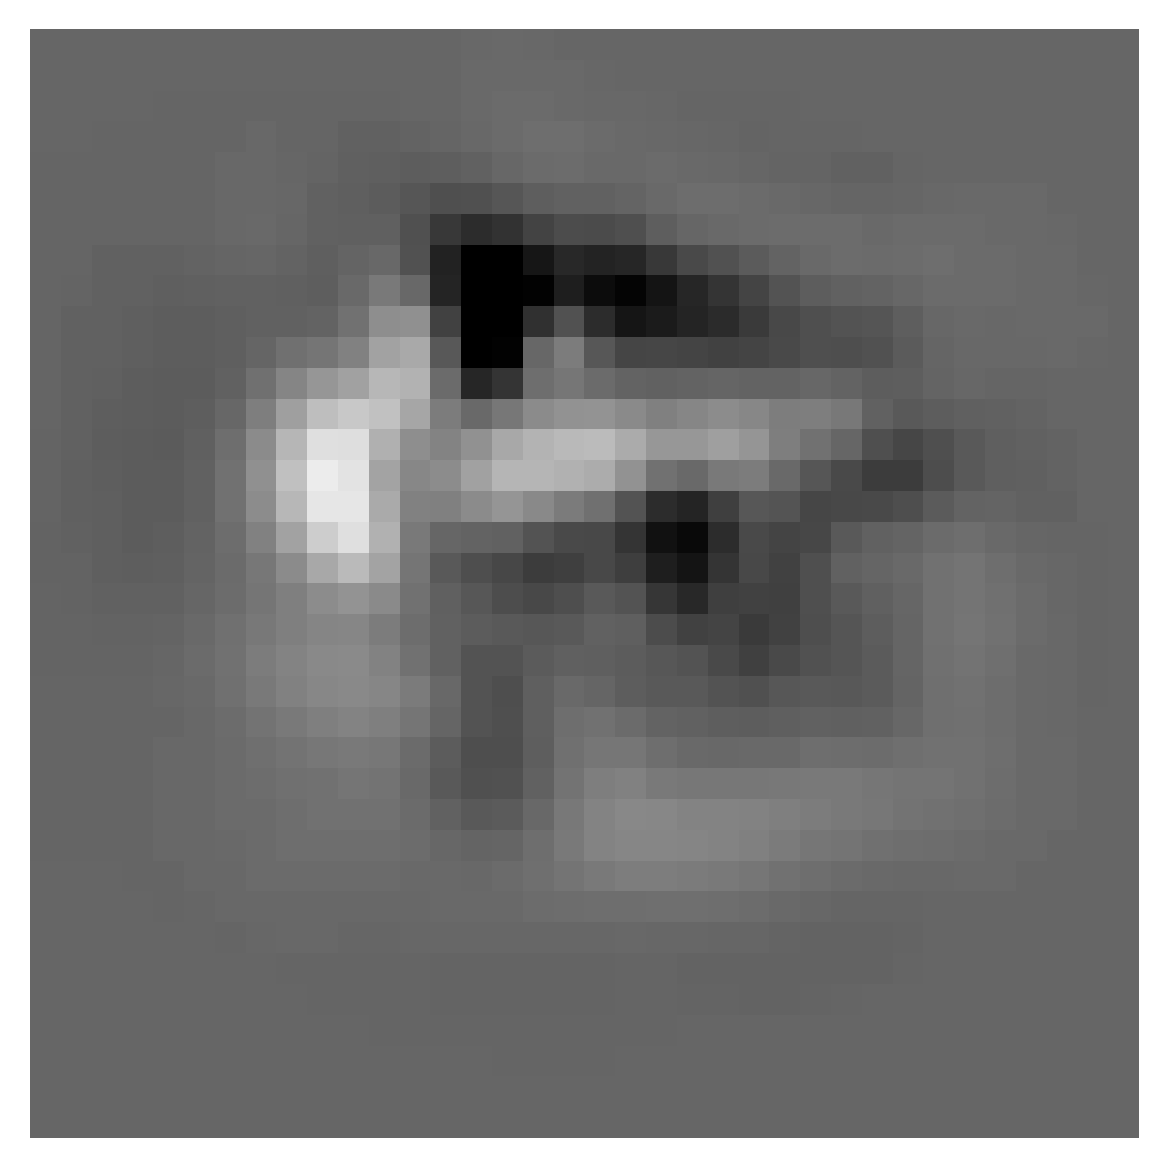

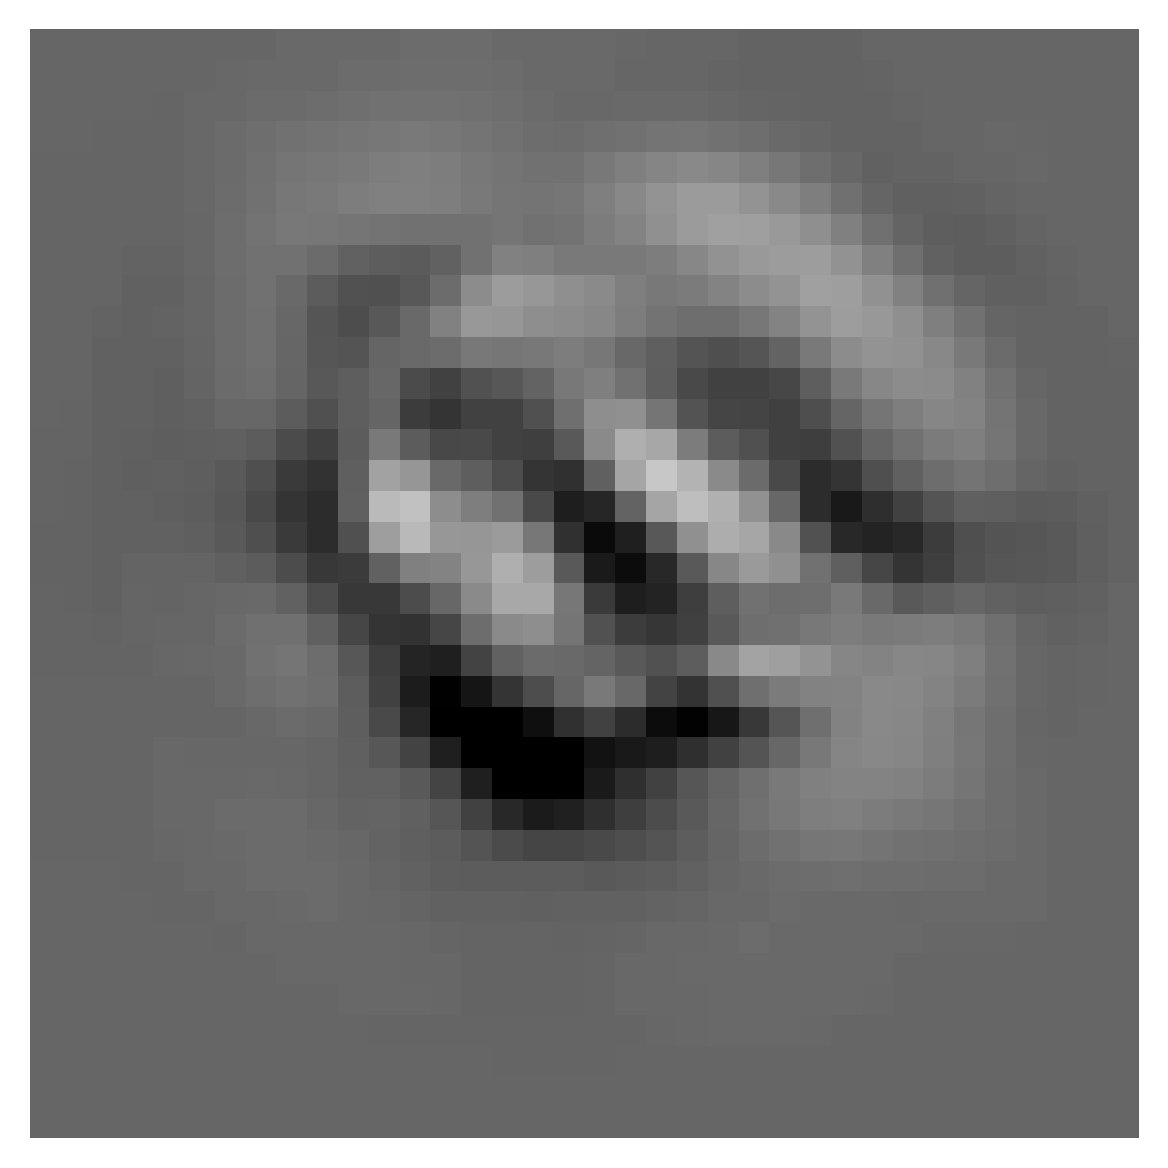

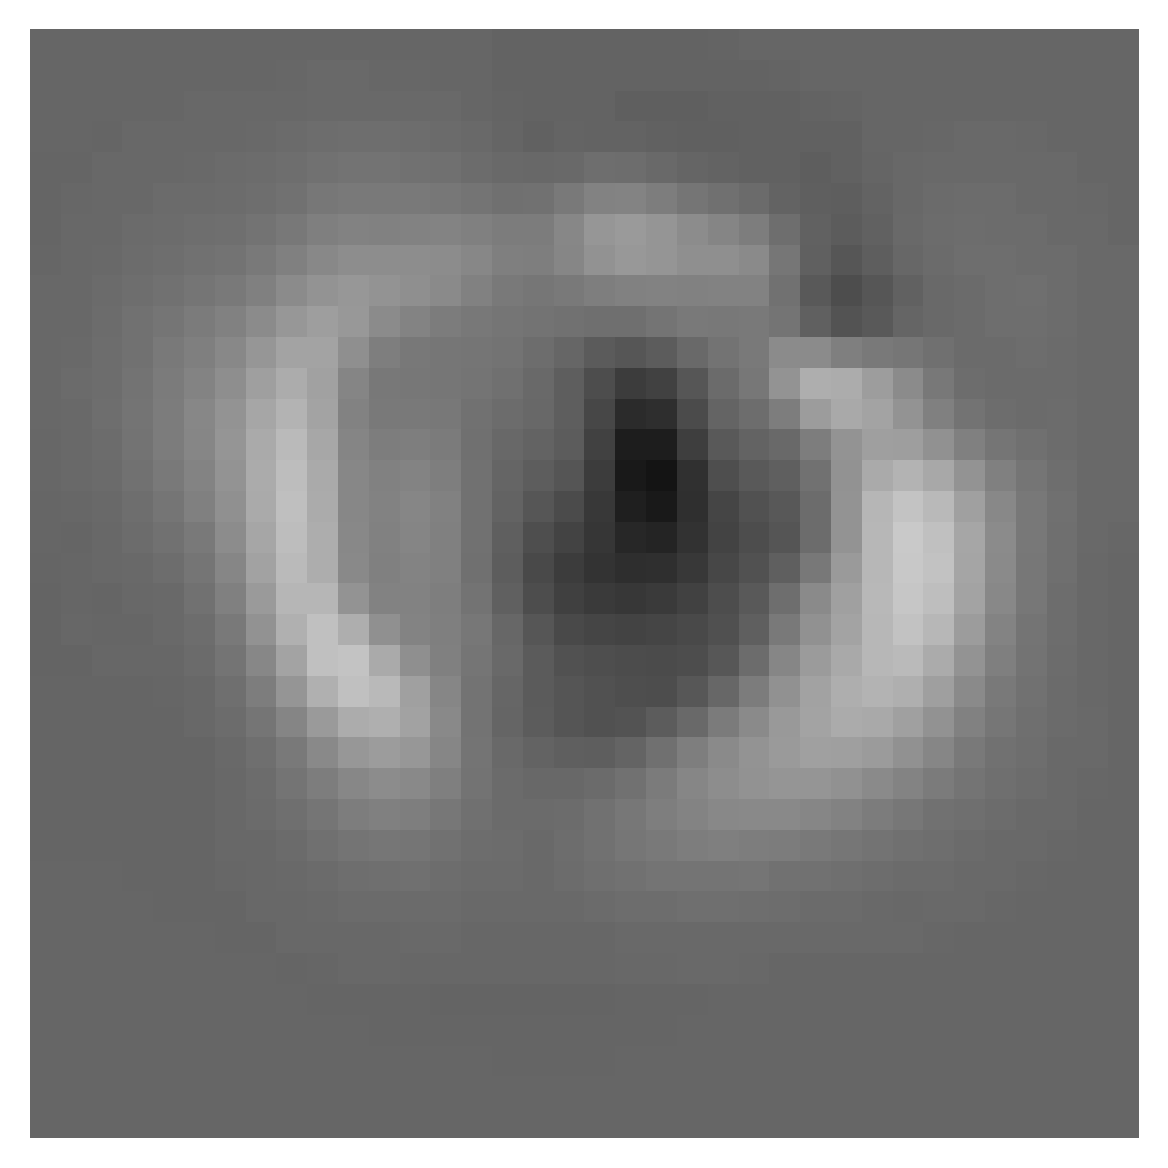

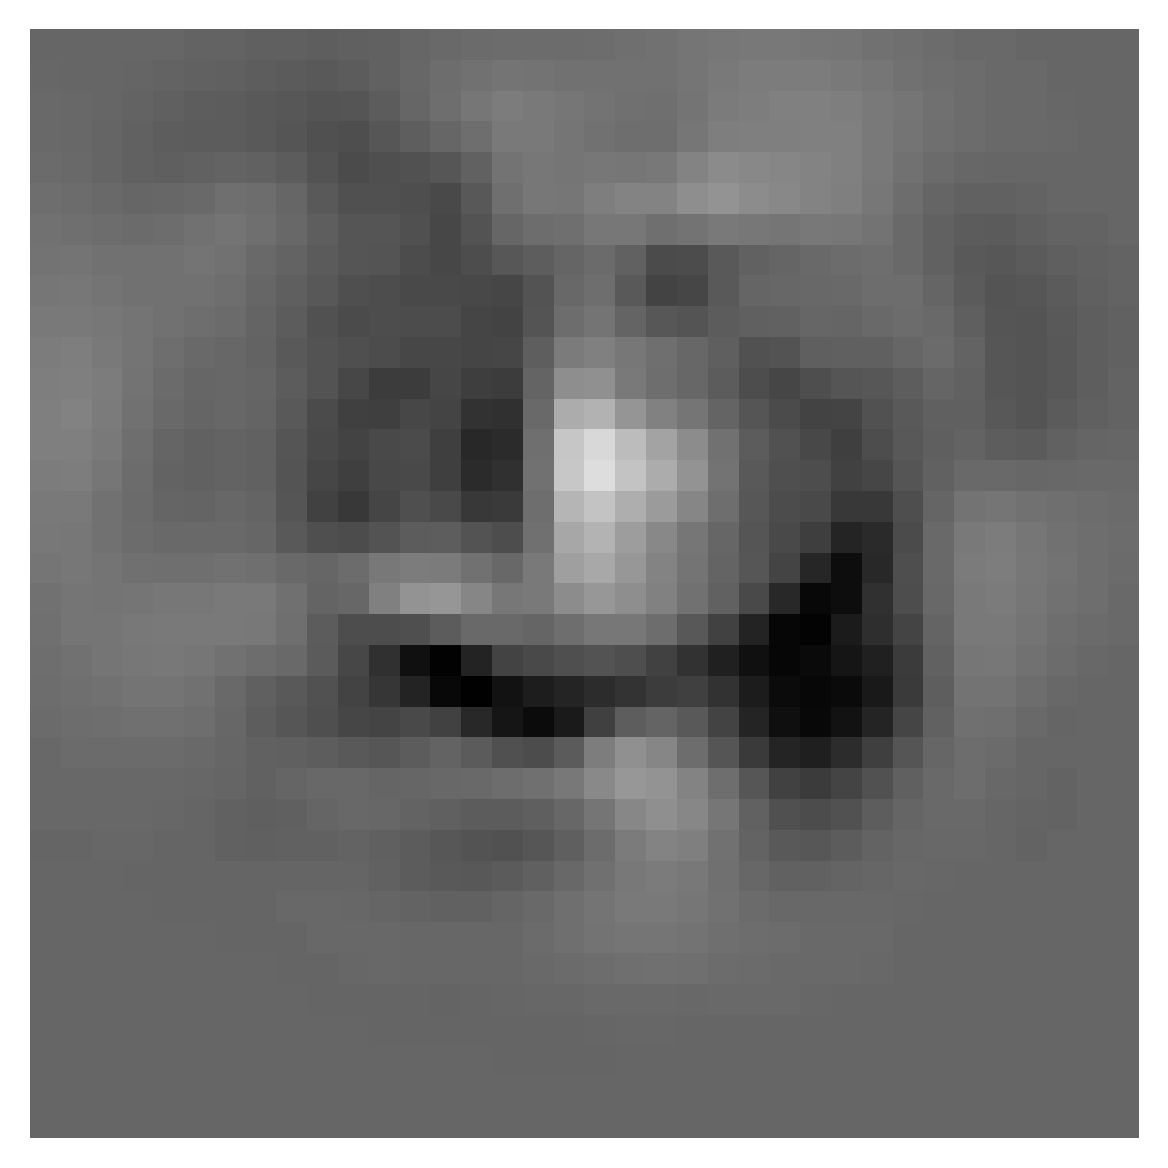

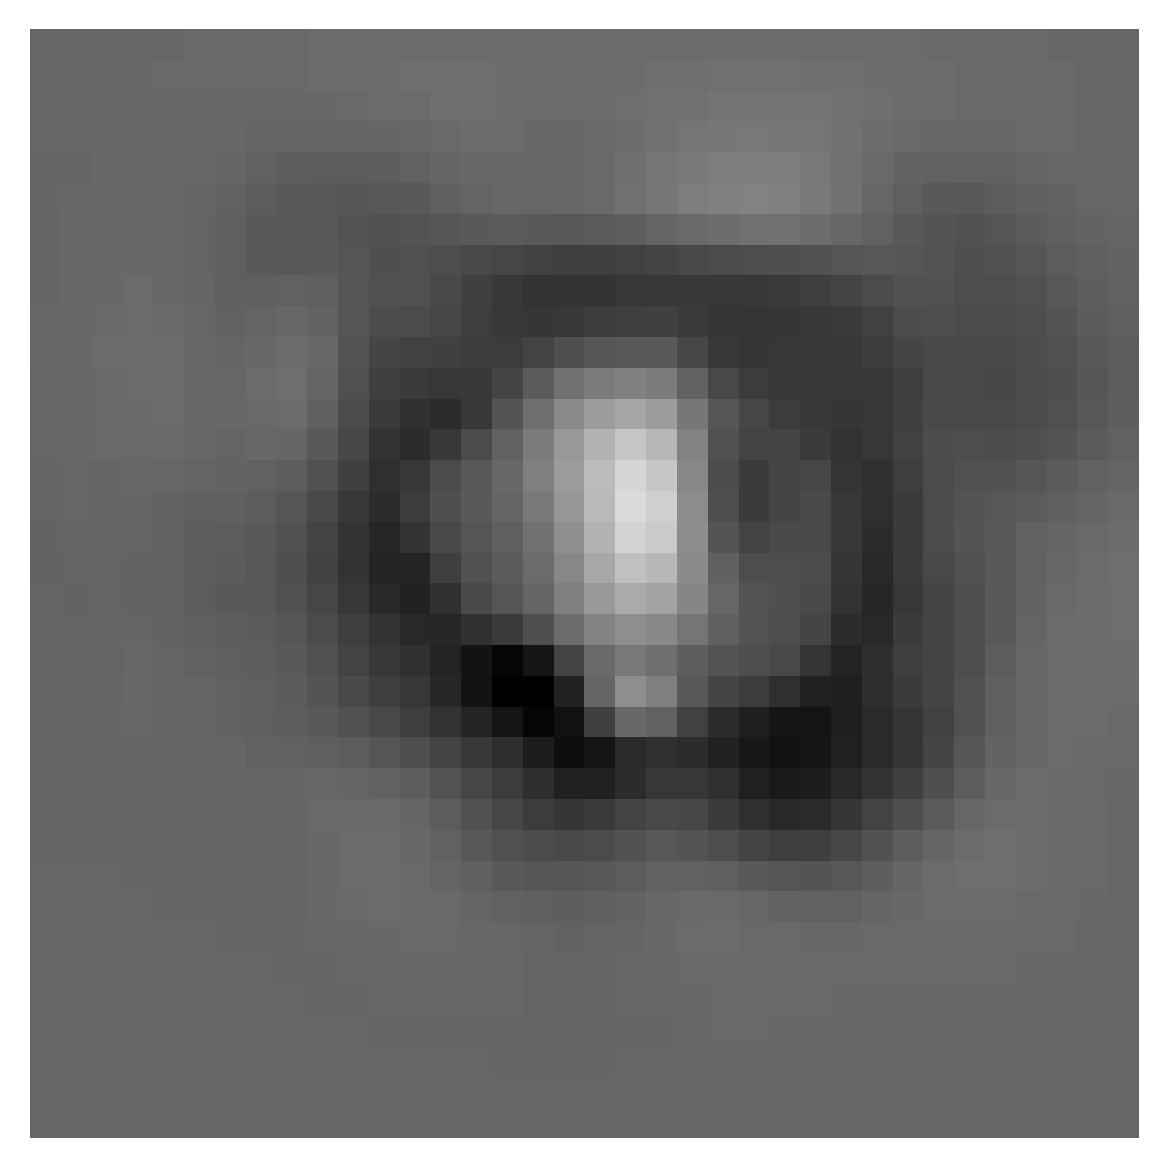

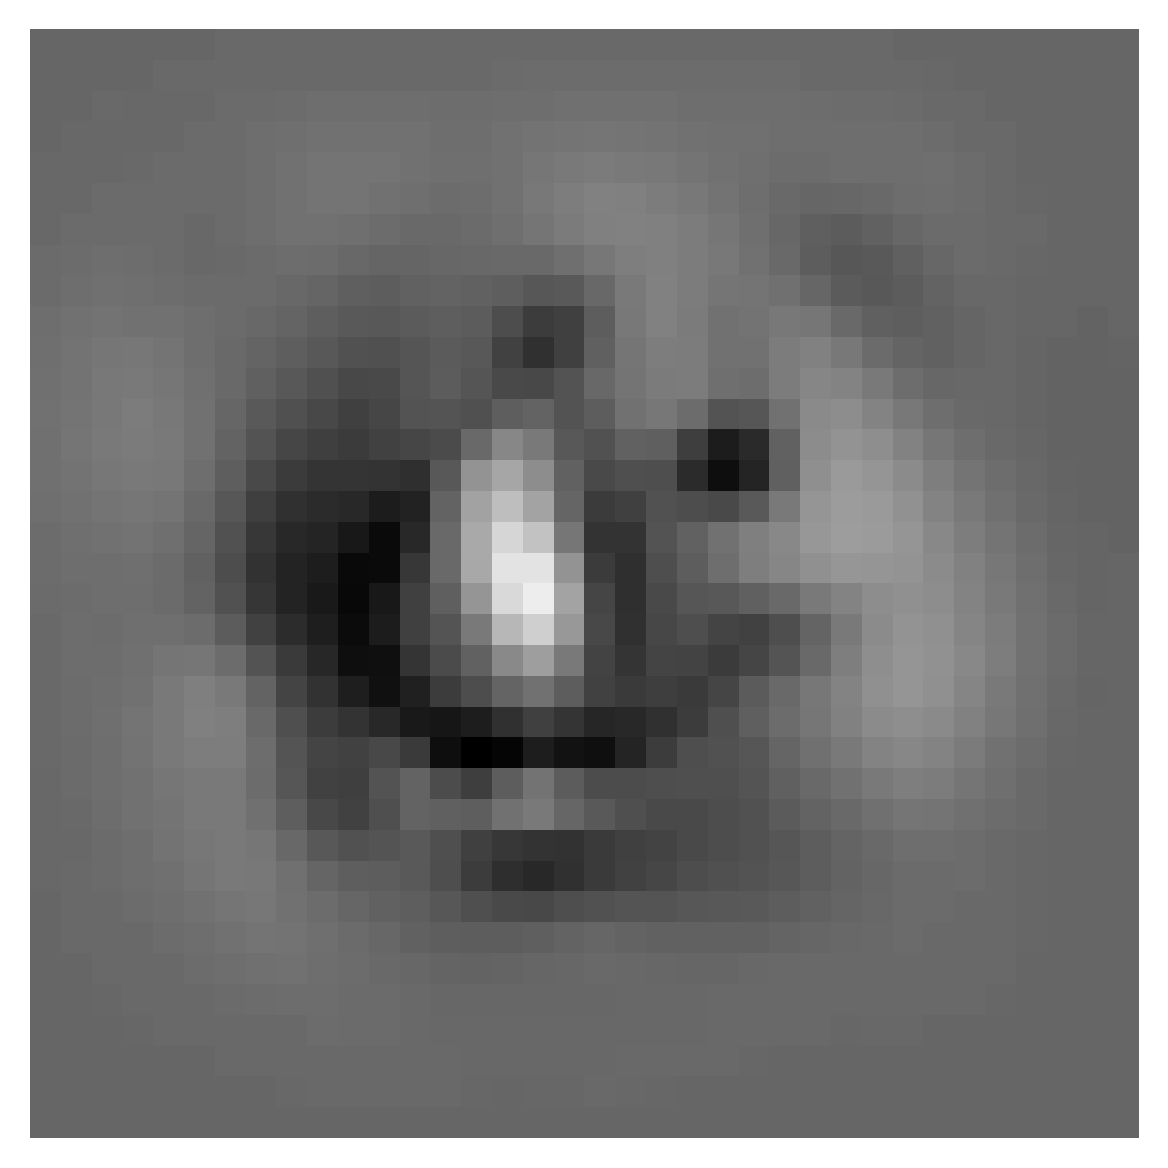

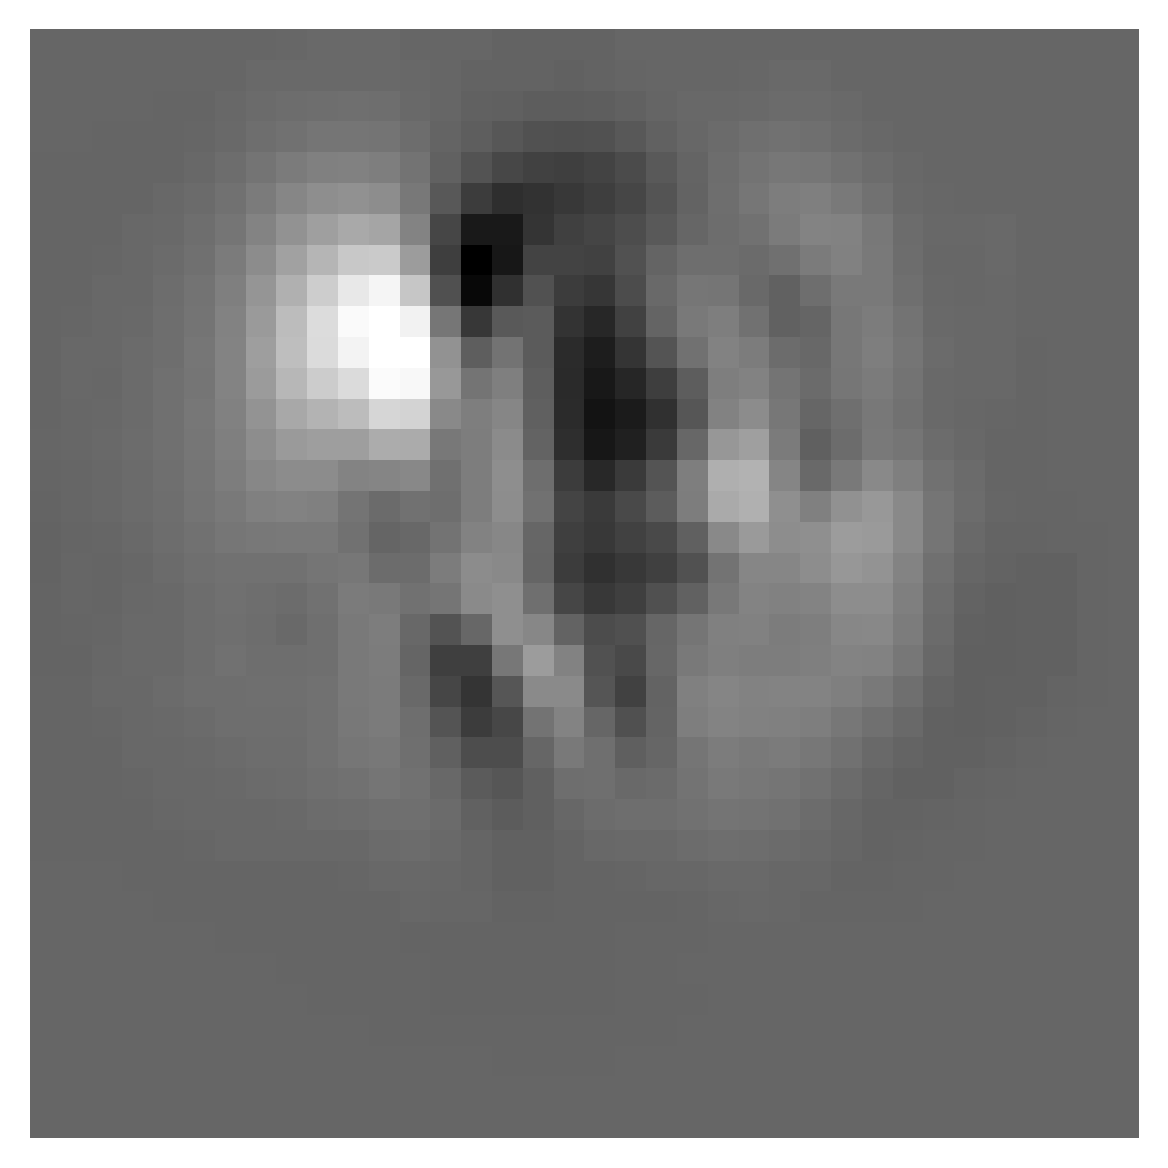

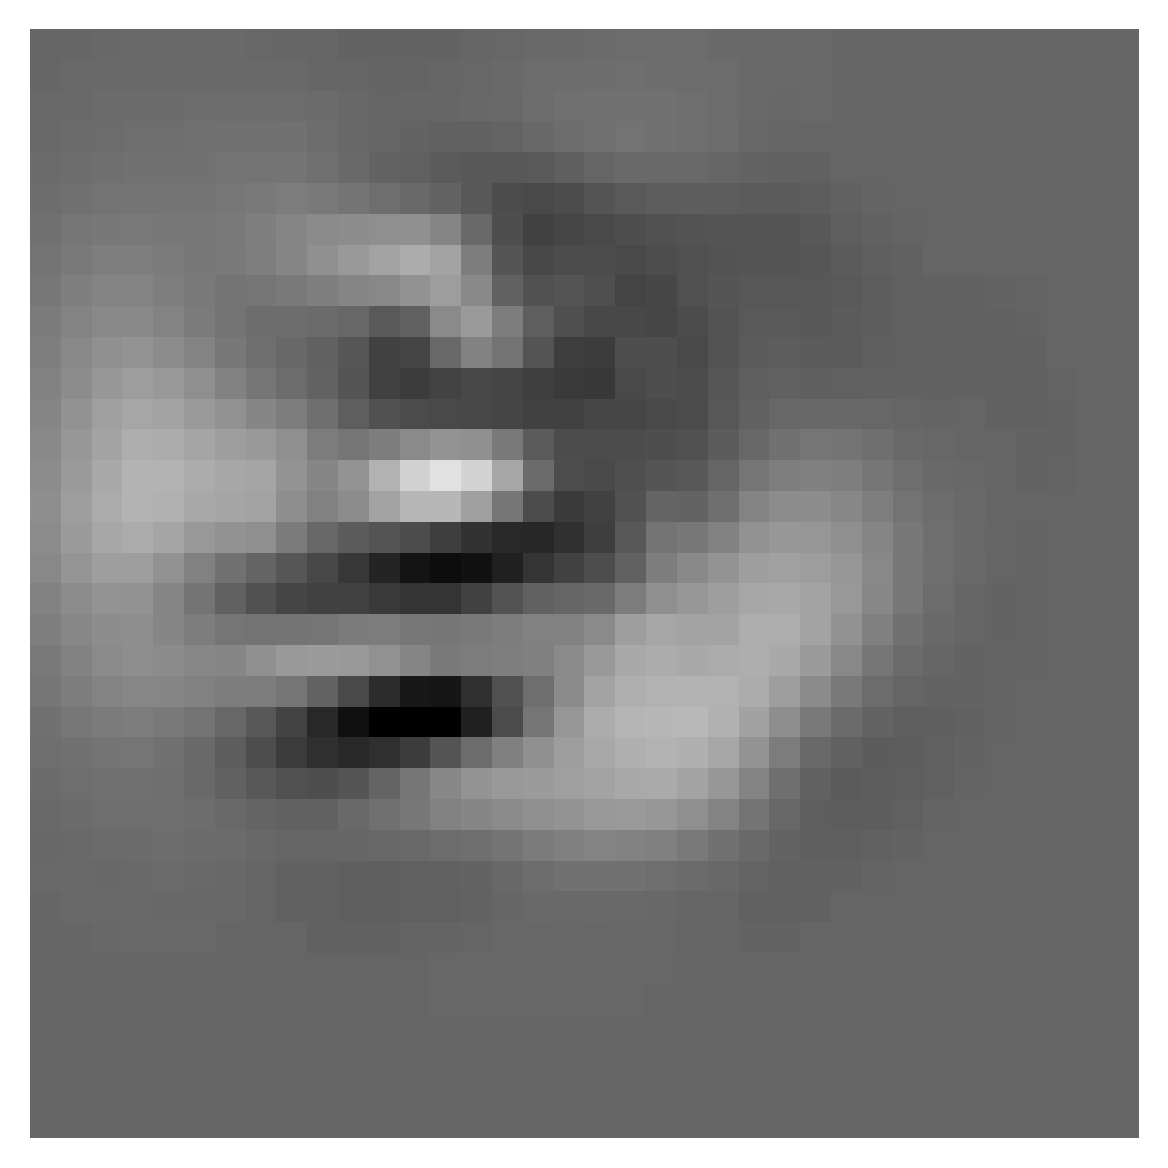

In [14]:
for idx, pattern in enumerate(patterns):
    fig, axs = plt.subplots(dpi=300)
    axs.imshow(pattern*2, cmap="gray", vmin=vmin, vmax=vmax)
    axs.axis("off")


Text(0.5, 1.0, 'Cos sim between assigned Gs')

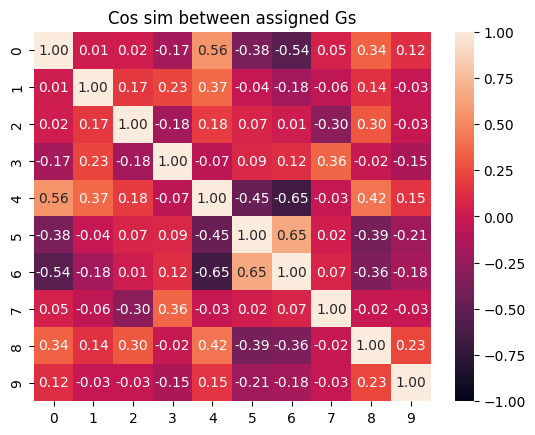

In [15]:
fig, ax = plt.subplots(dpi=100)
sns.heatmap(cossim, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Cos sim between assigned Gs")

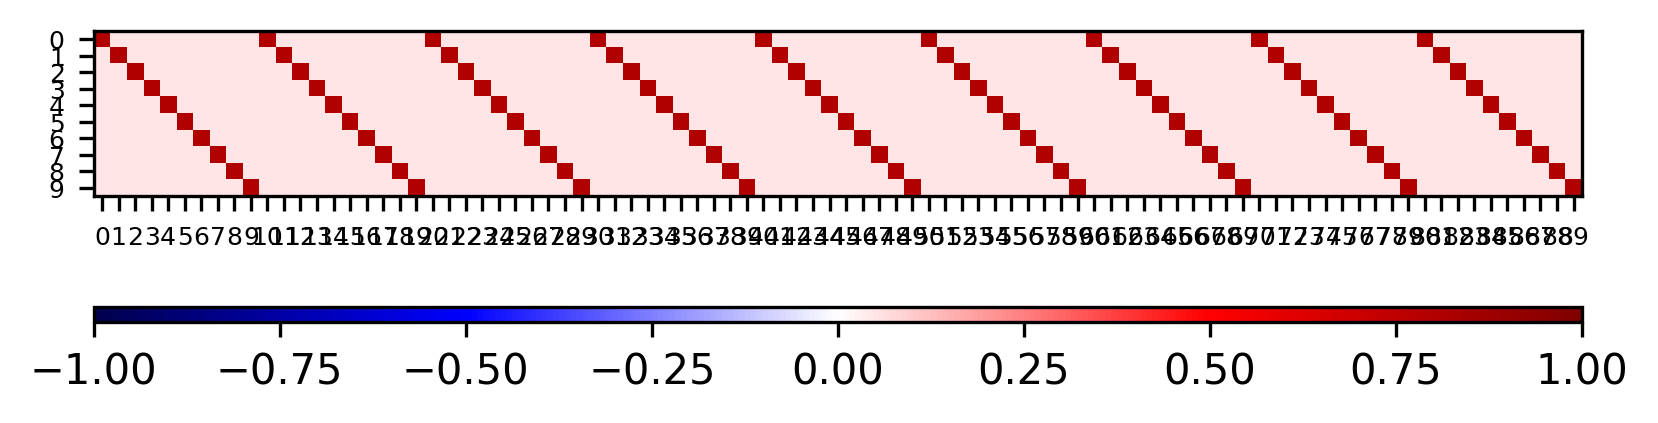

In [16]:
fig, ax = plt.subplots(dpi=300)
ax.imshow(model.G_X_mapping.T, cmap="seismic", vmin=-1, vmax=1)
ax.set_xticks(np.arange(G_dim*9))
ax.set_xticklabels(np.arange(G_dim*9))
ax.set_yticks(np.arange(G_dim))
ax.set_yticklabels(np.arange(G_dim))
ax.tick_params(axis='both', which='major', labelsize=6)
# draw a small horizontal colorbar
cbar = fig.colorbar(ax.get_images()[0], ax=ax, orientation="horizontal", pad=0.1, aspect=100)

<Axes: ylabel='Count'>

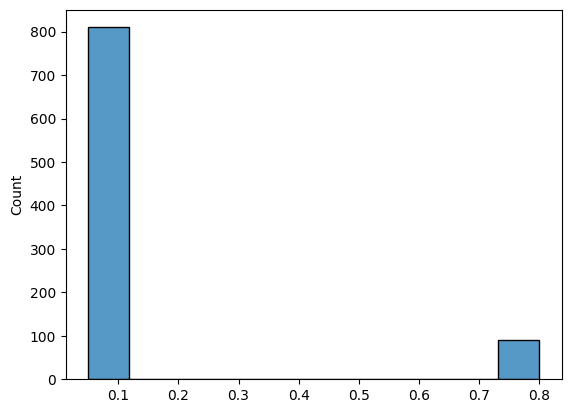

In [17]:
sns.histplot(model.G_X_mapping.flatten())

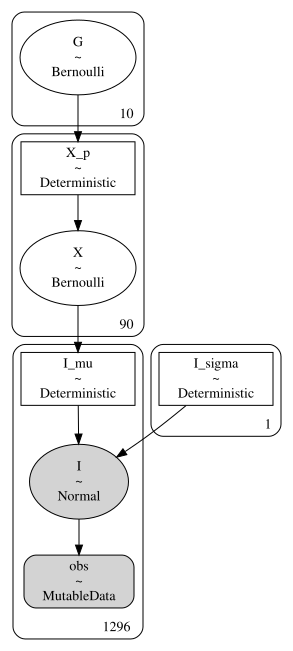

In [18]:
pm.model_to_graphviz(model.prob_model)

In [19]:
prior_samples_dict = model.sample_prior_predictive(n_samples=100, random_seed=1)

Sampling: [G, I, X]


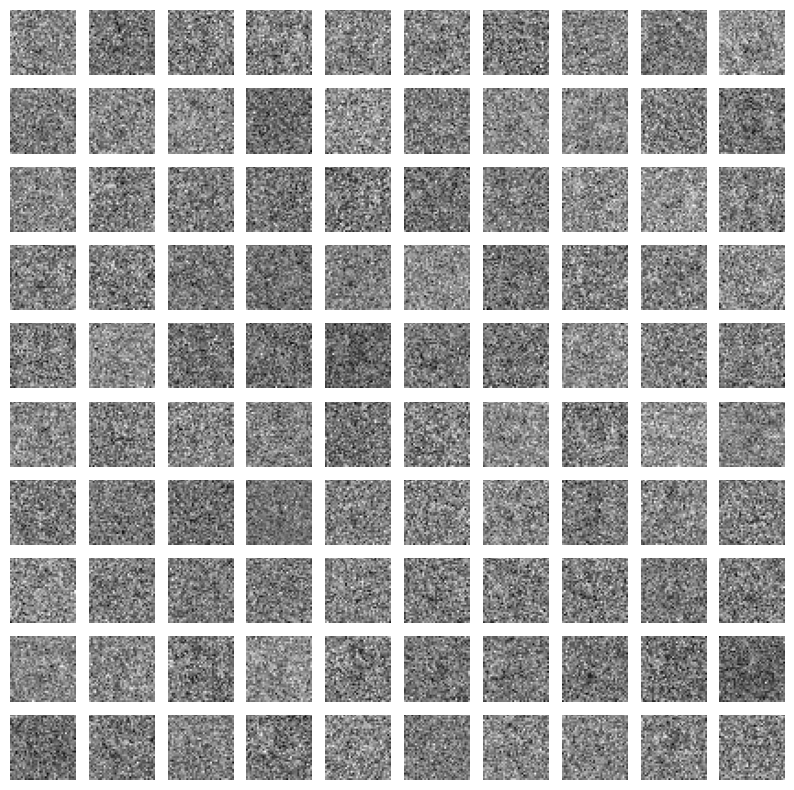

In [20]:
fig, axs = plt.subplots(10, 10, figsize=(10, 10))
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(prior_samples_dict["I"][idx], cmap="gray")
    ax.axis("off")

In [21]:
MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2, disrupting_pattern_indices = create_stimuli(patterns)

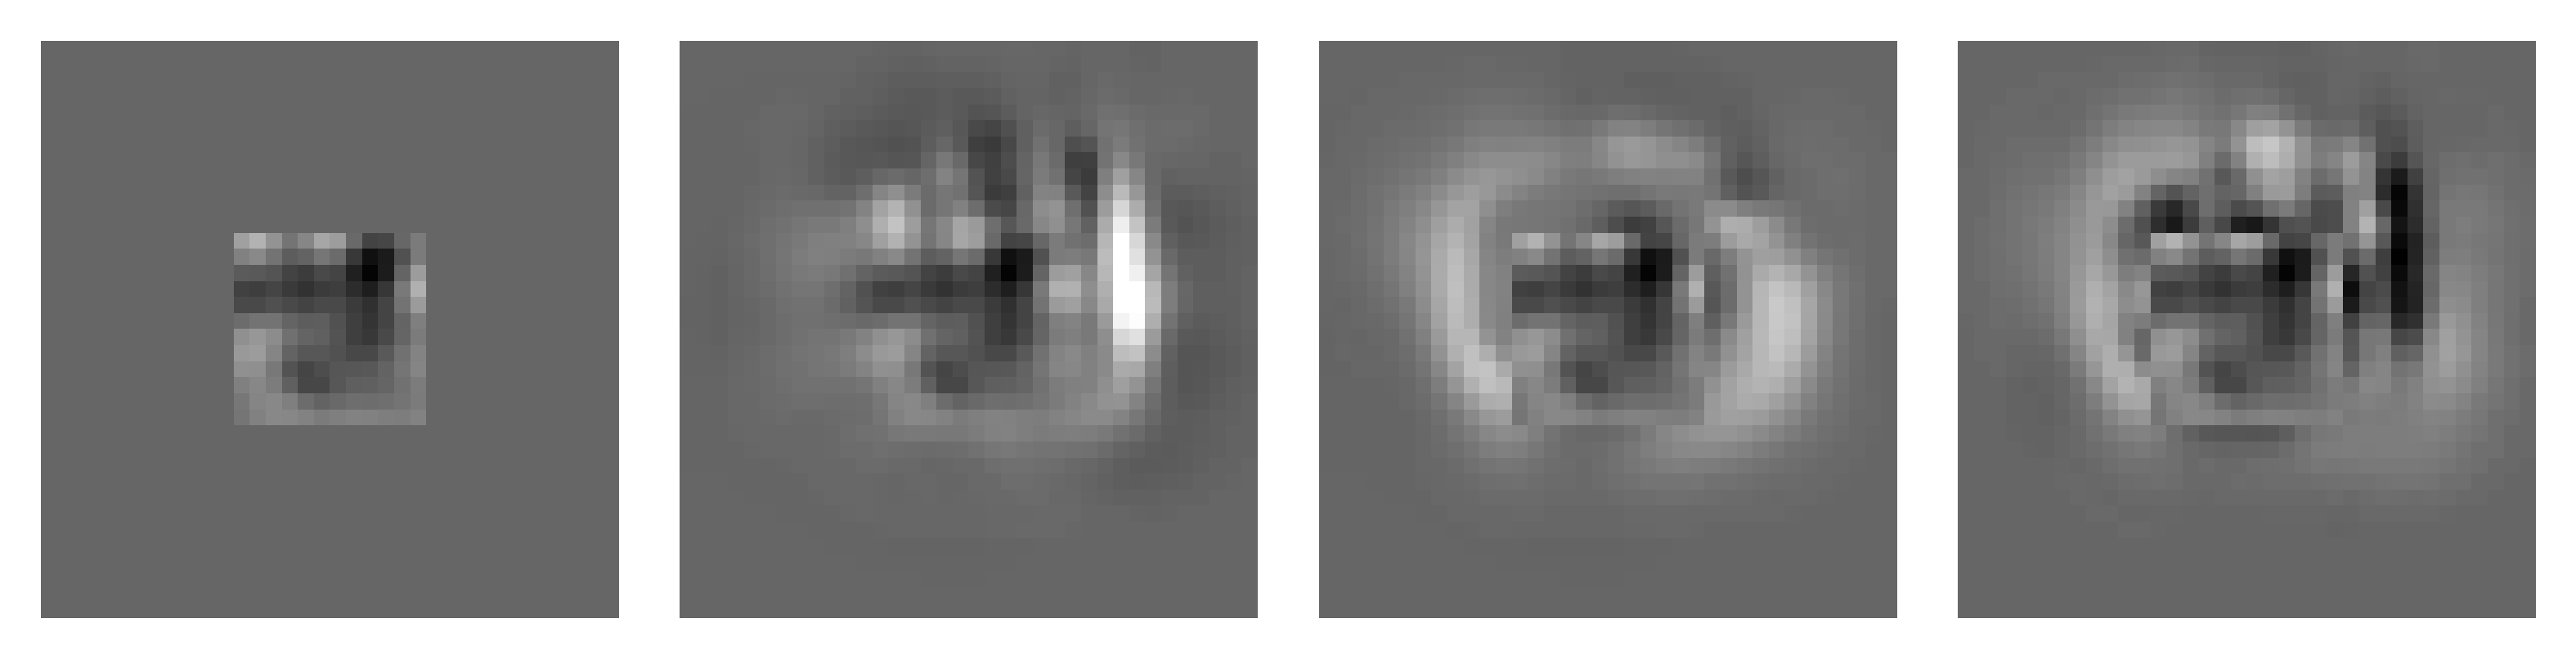

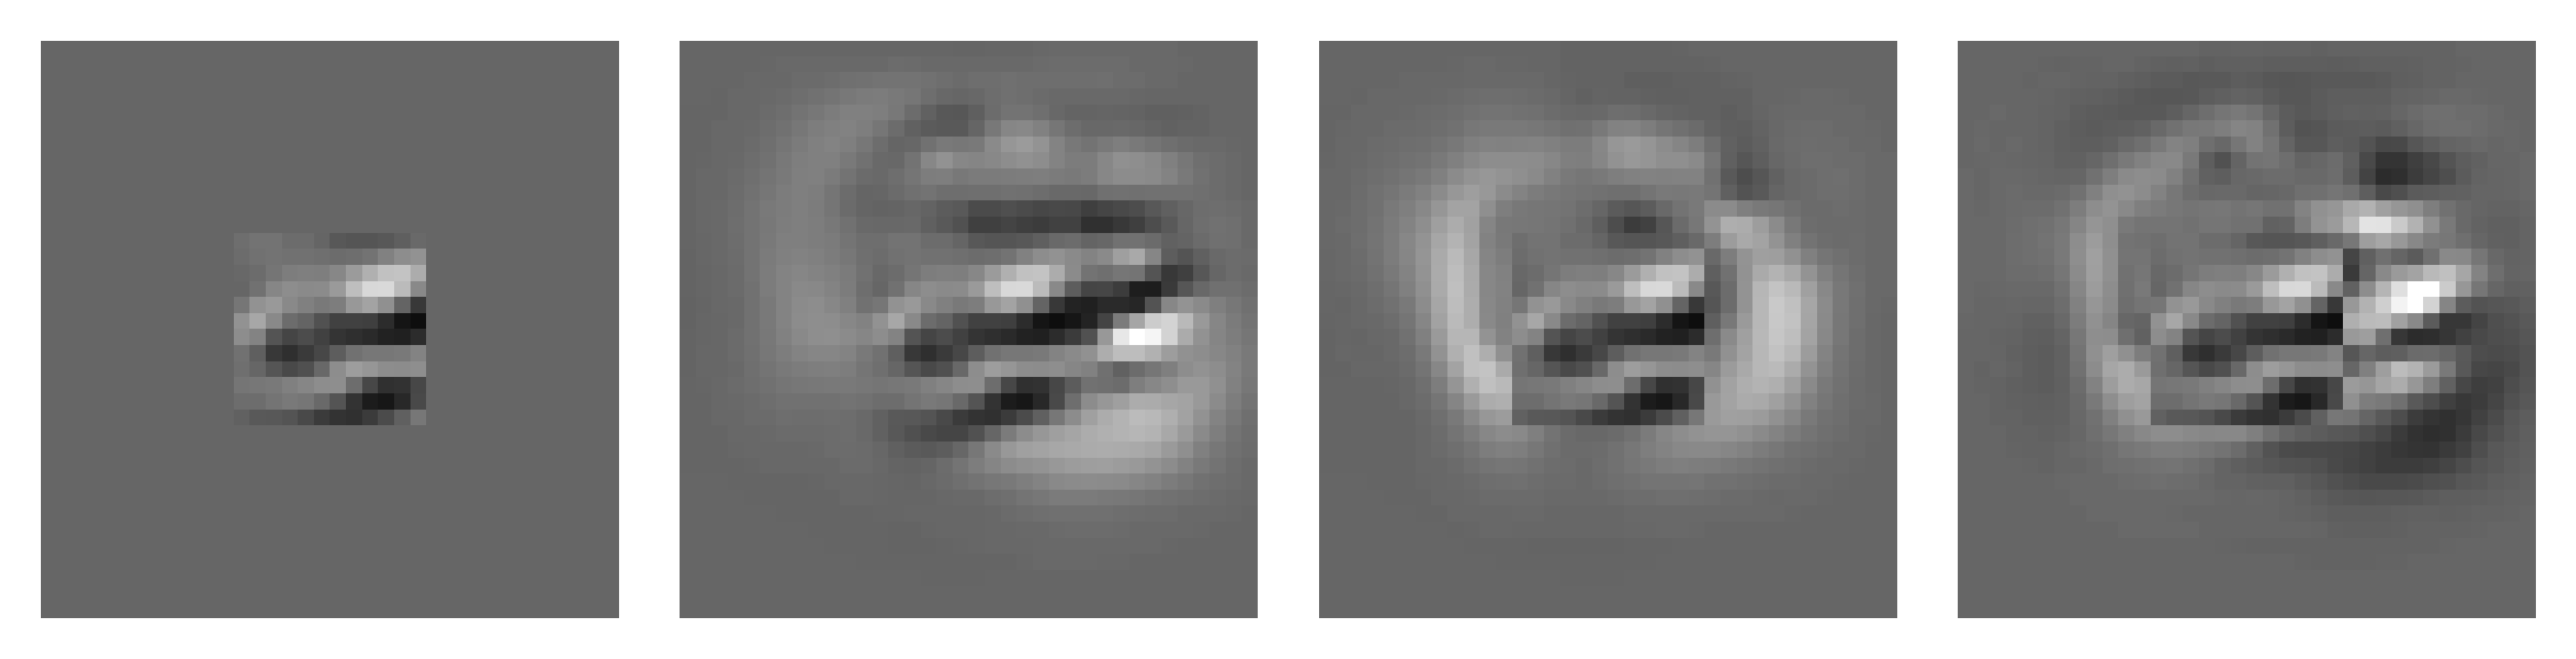

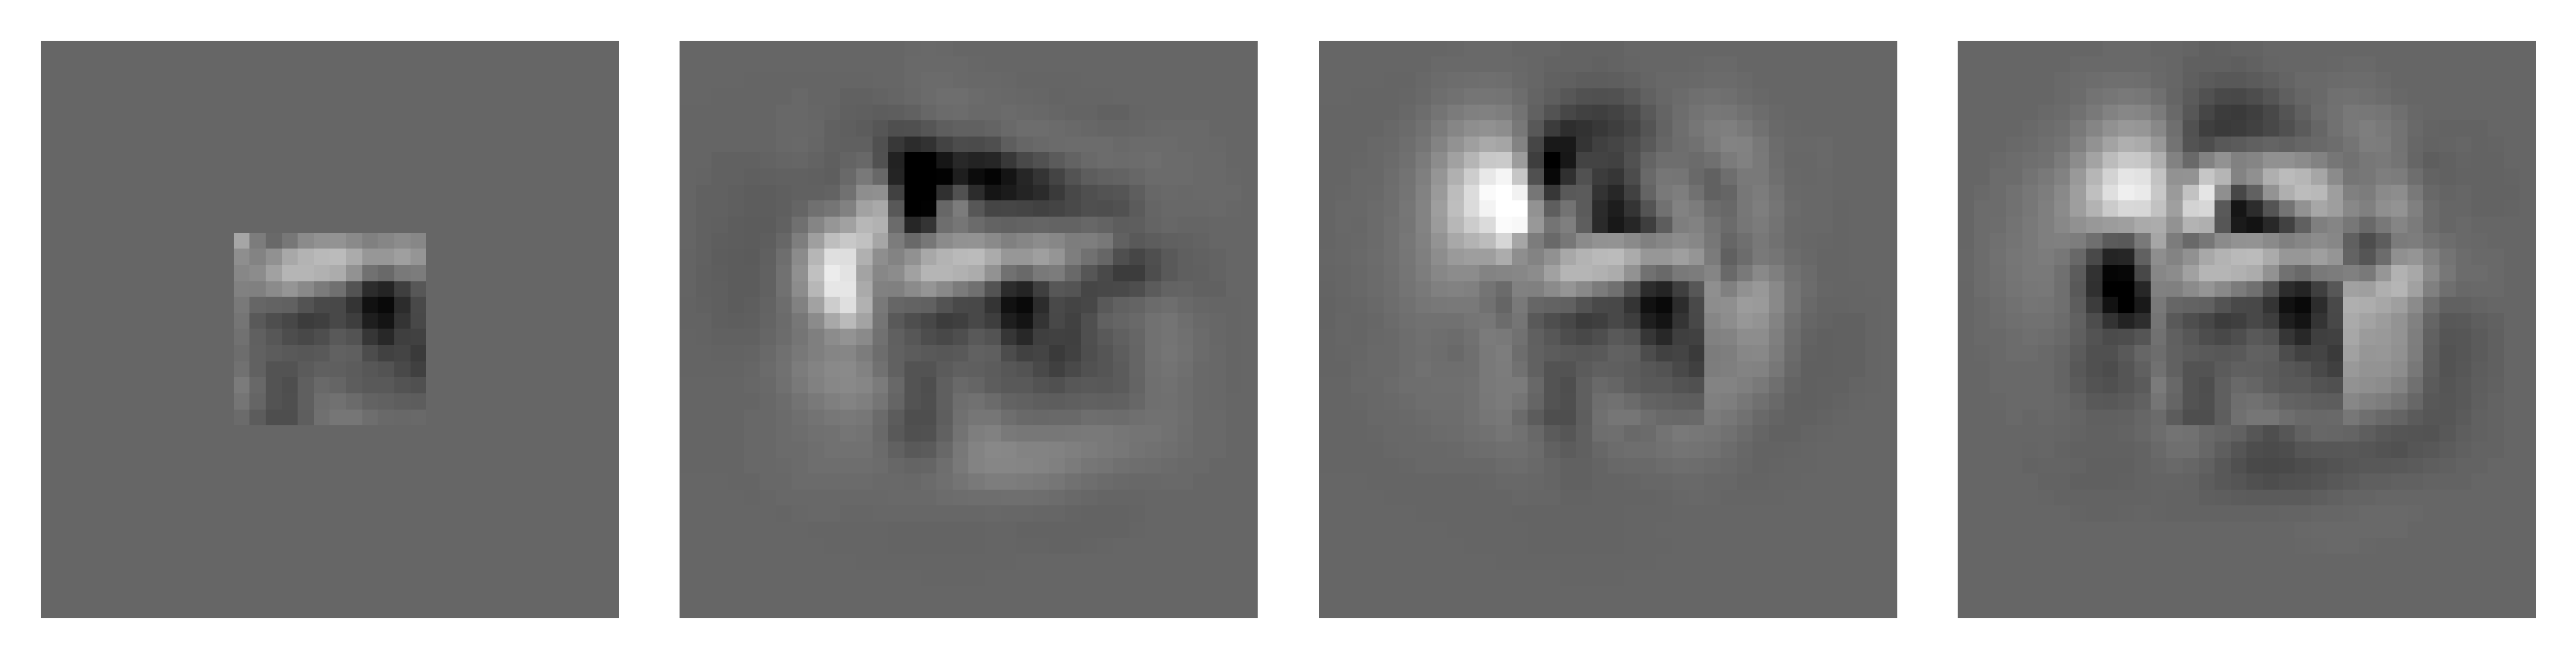

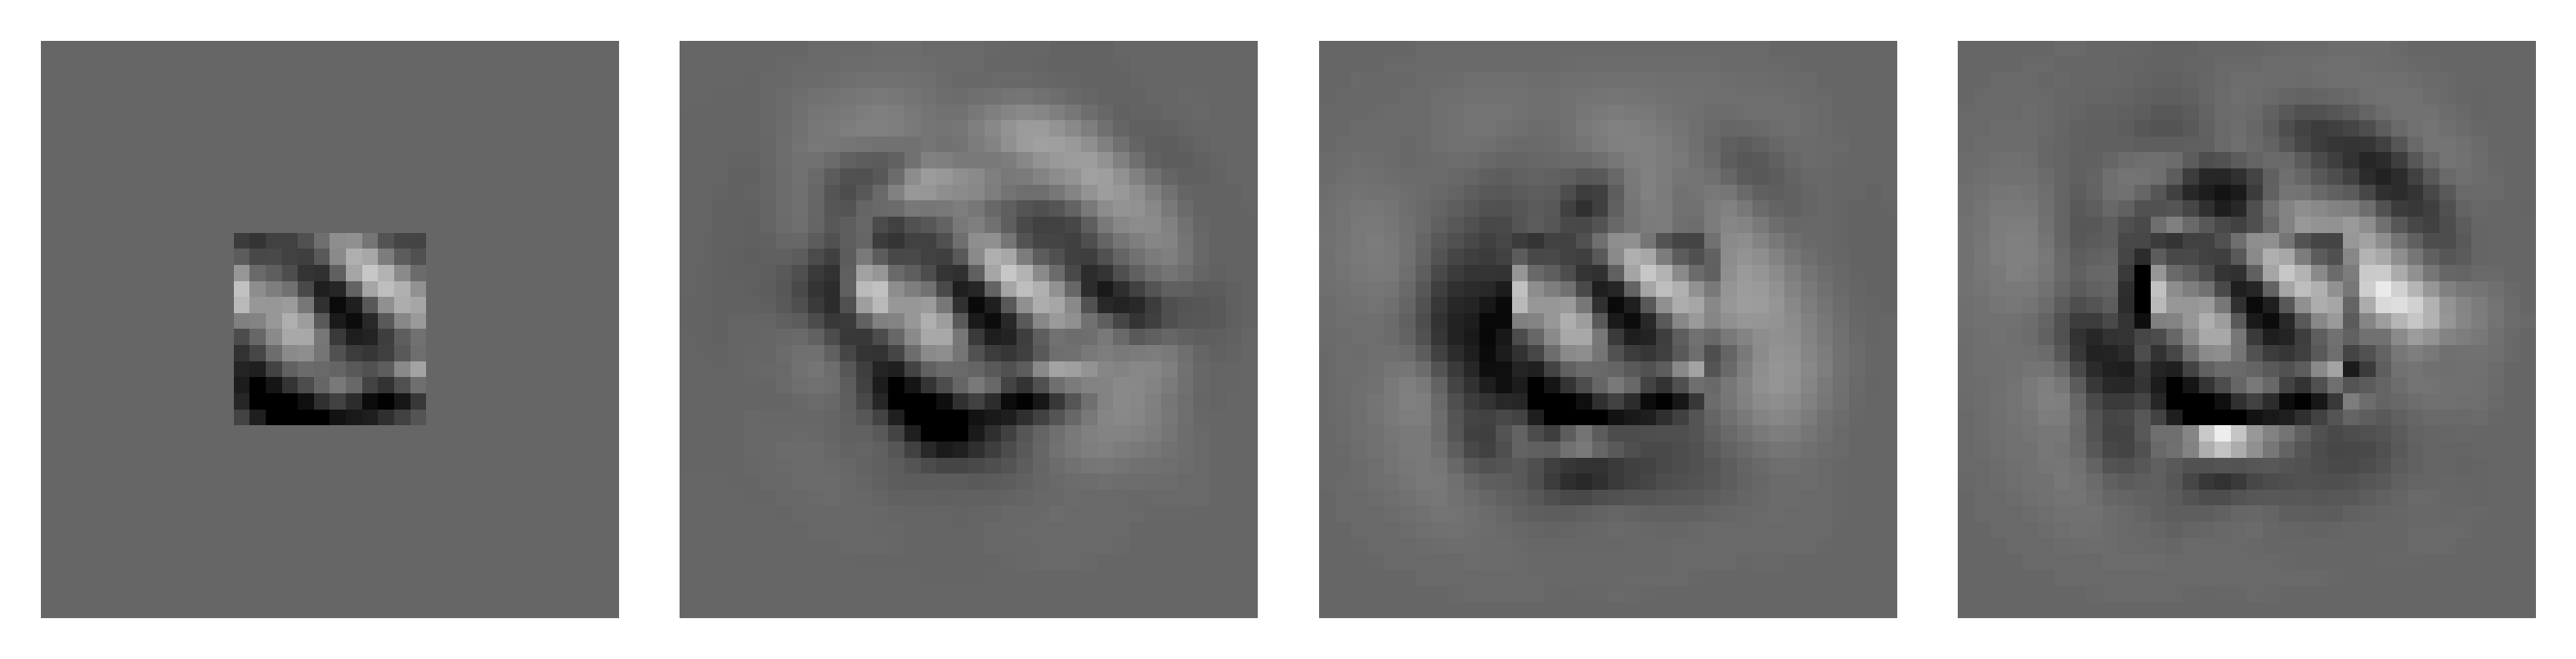

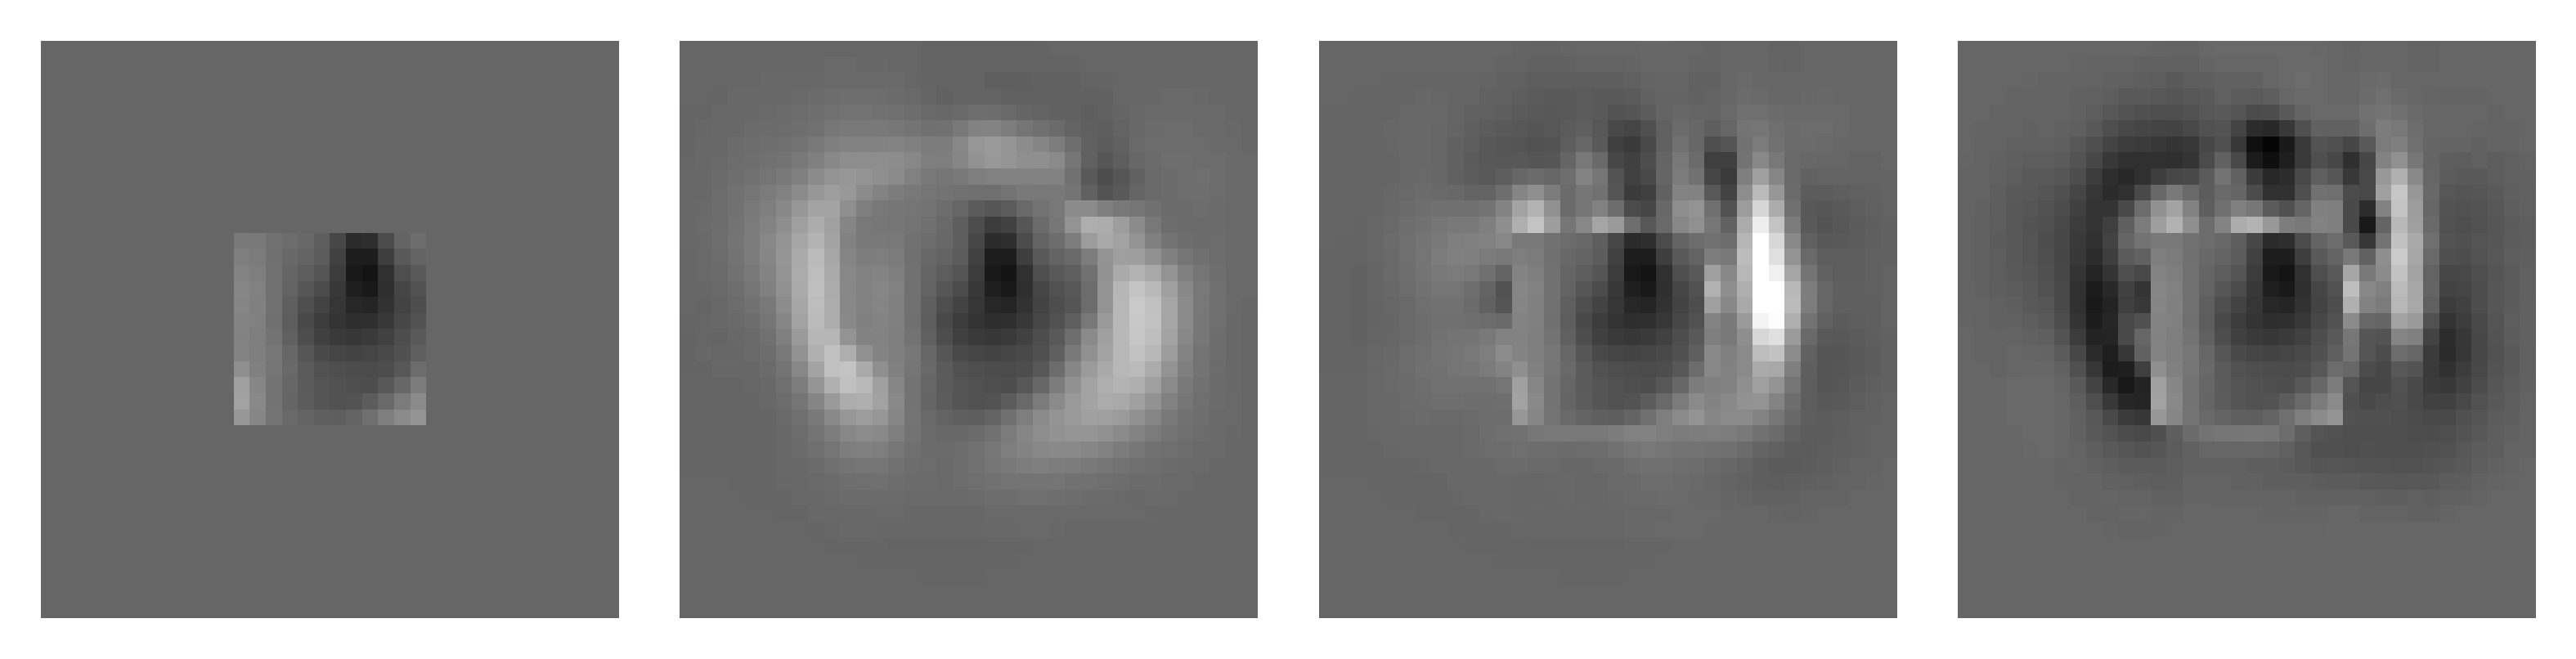

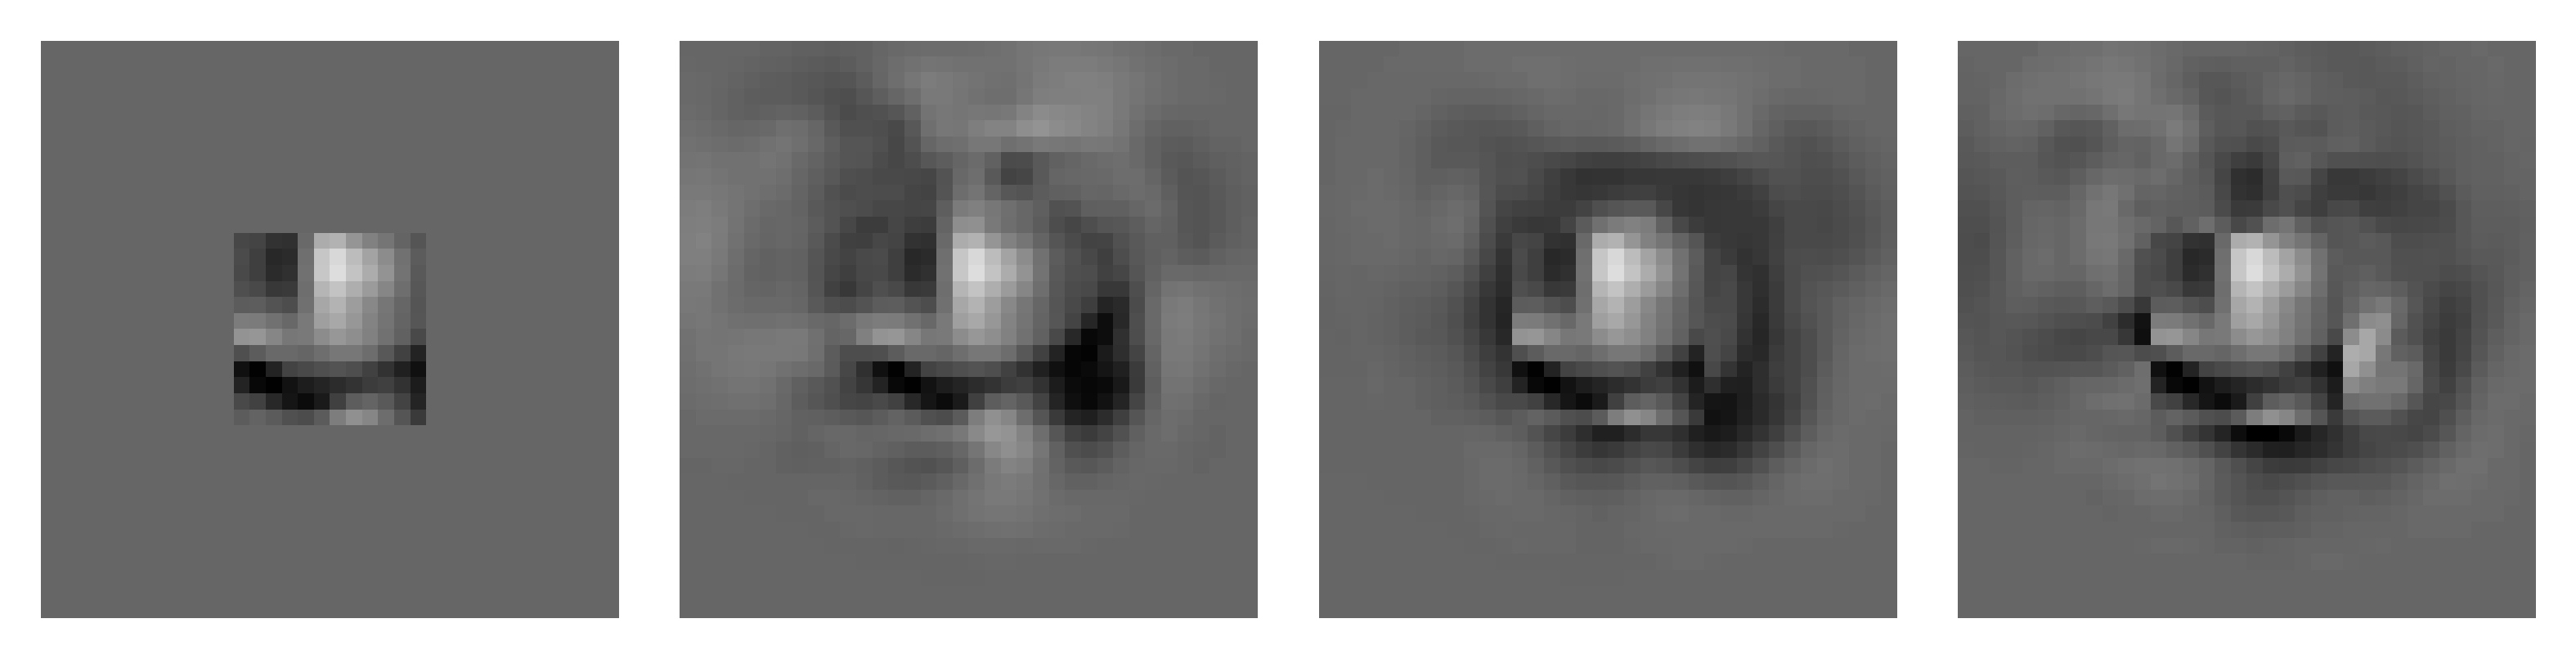

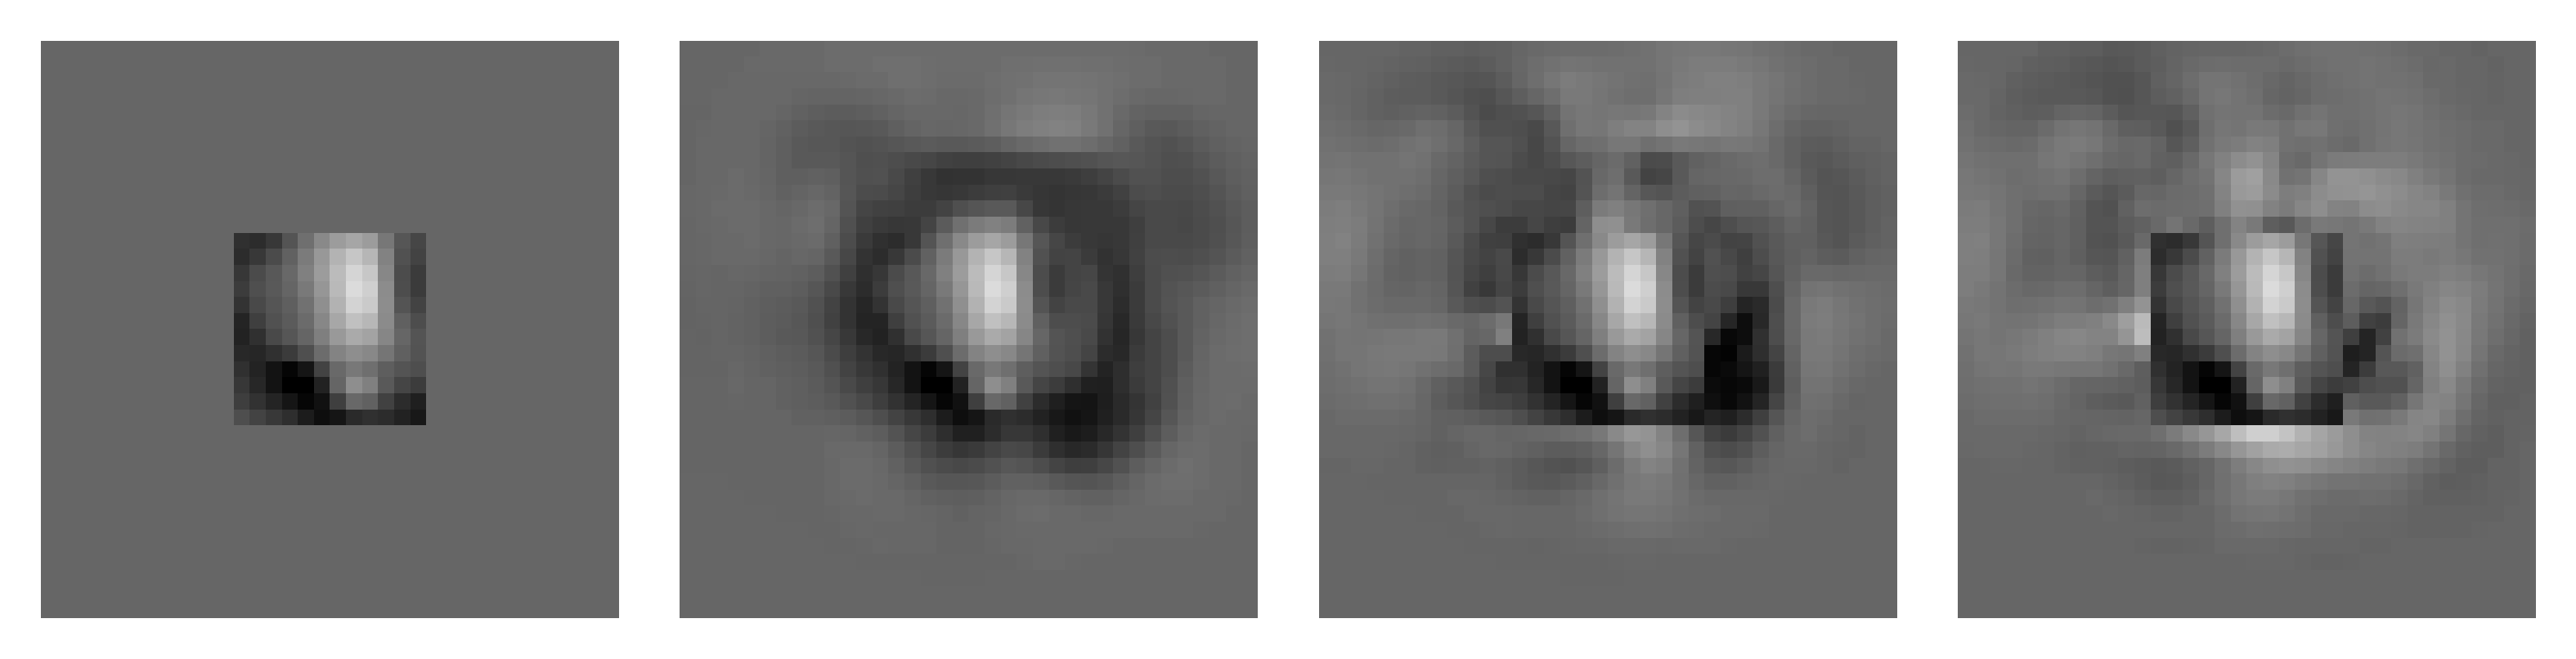

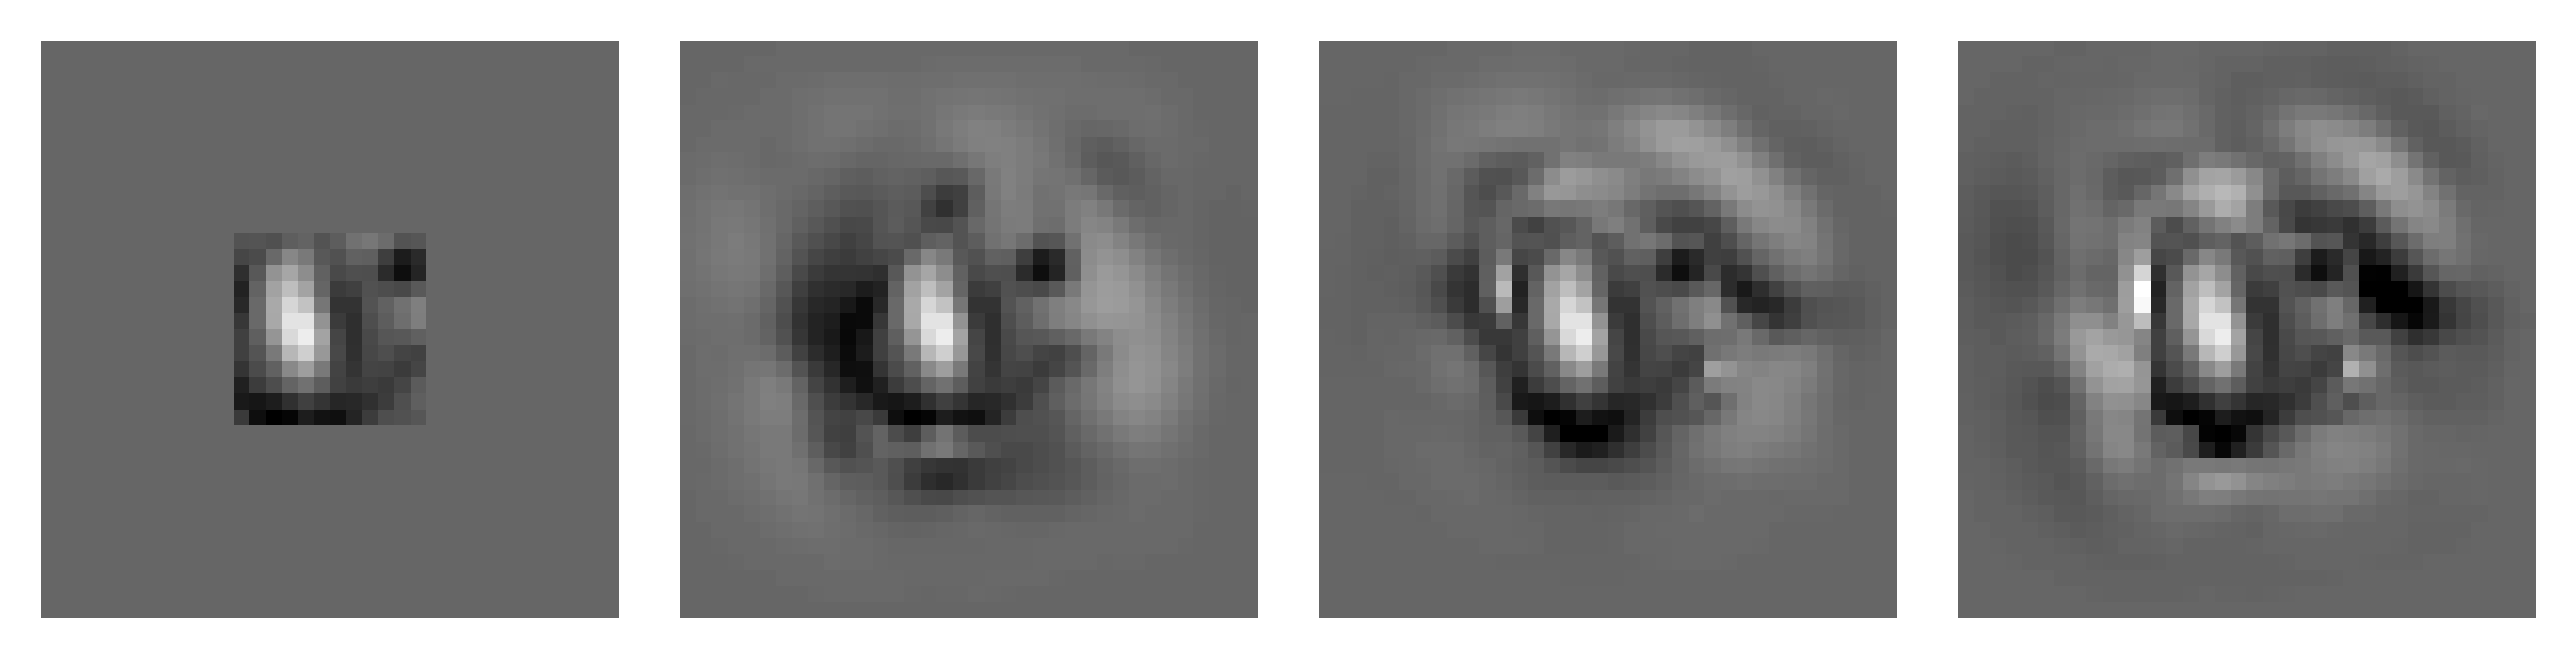

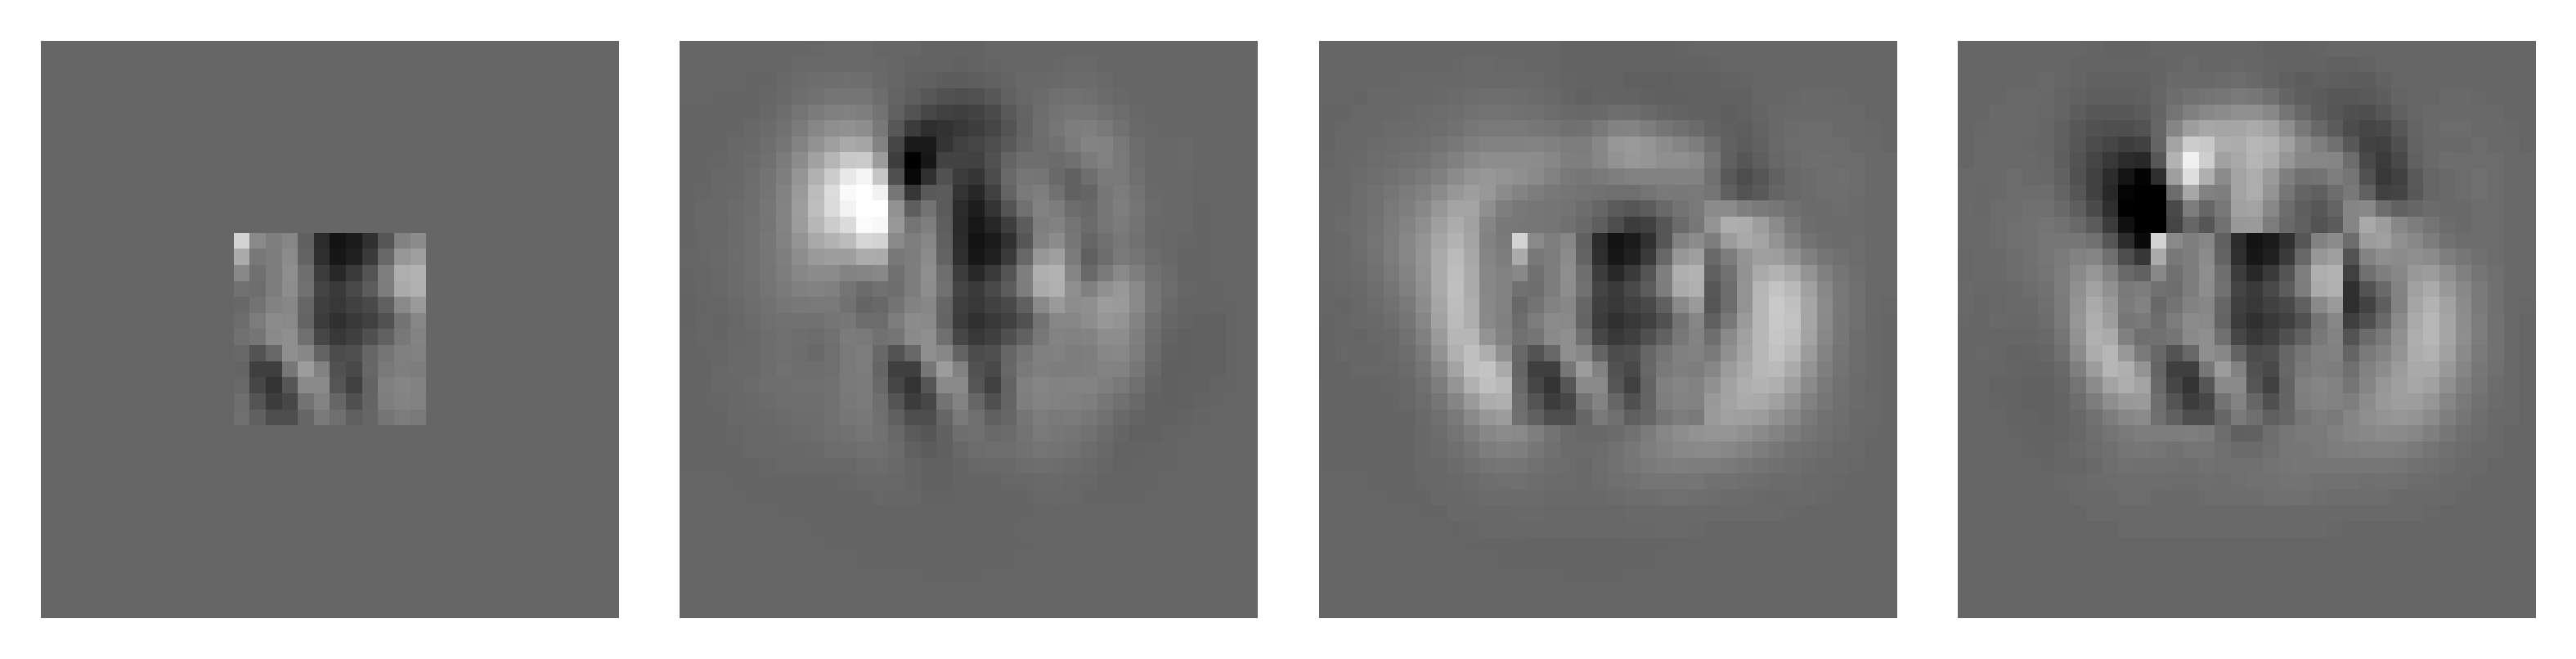

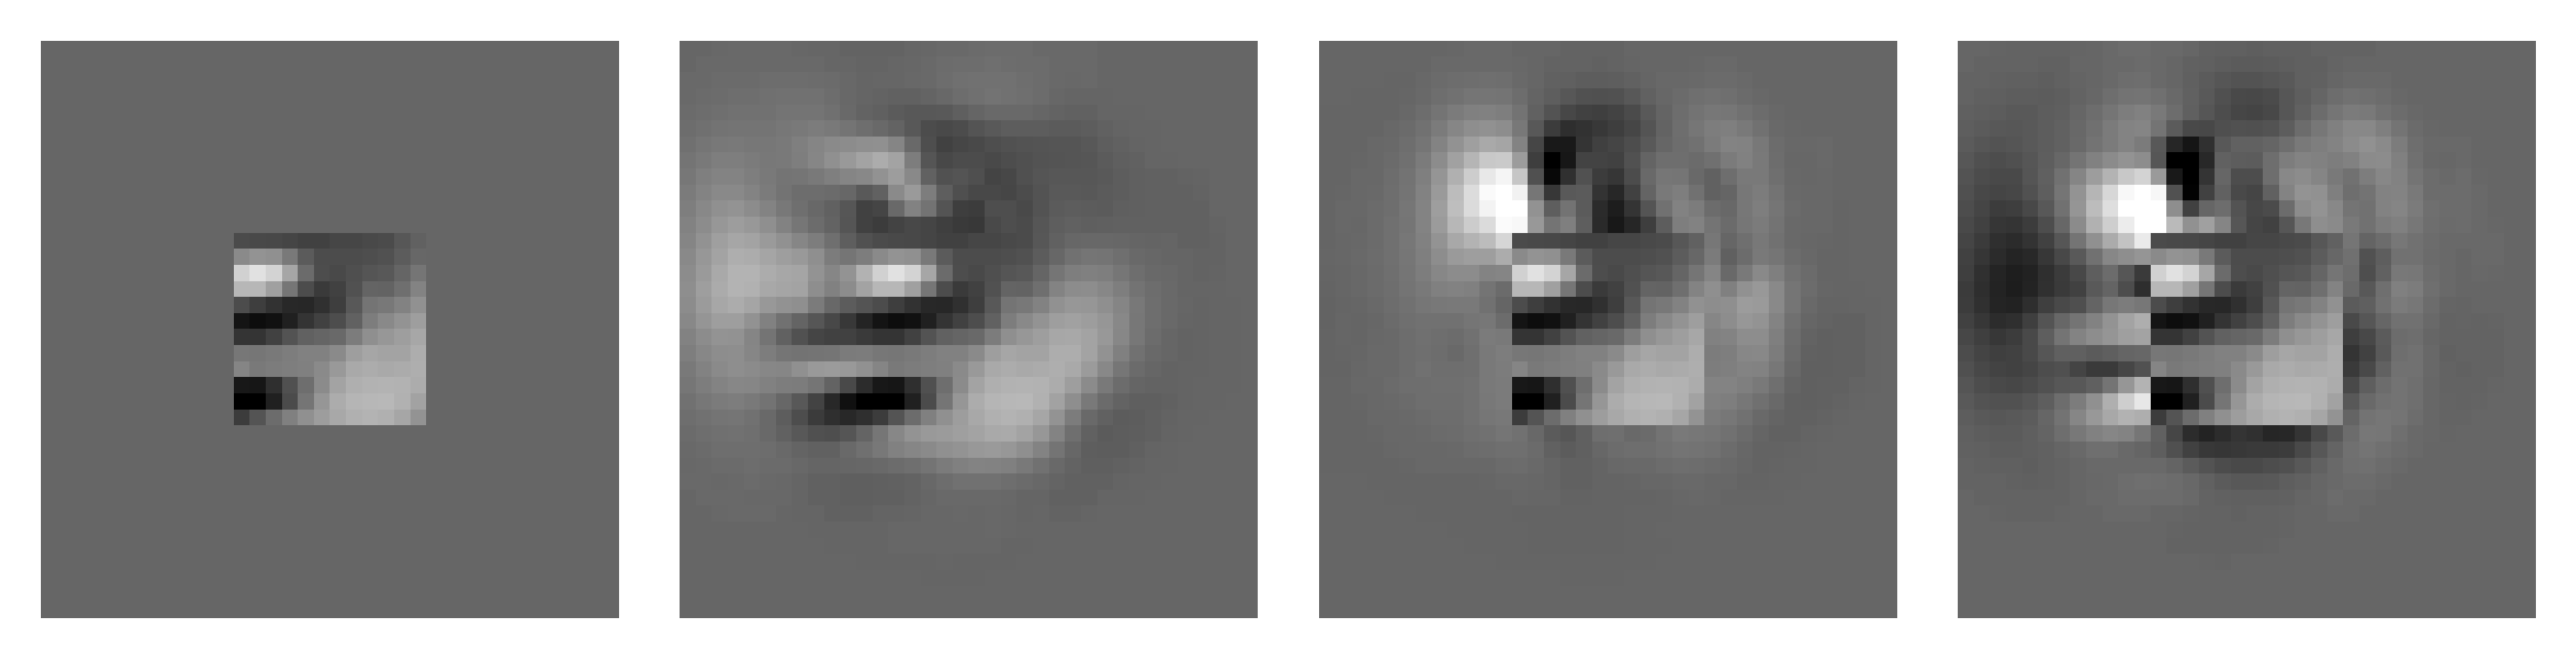

In [23]:
for idx, (MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2) in enumerate(zip(MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2)):
    fig, axs = plt.subplots(1, 4, dpi=500)
    axs[0].imshow(MEI*2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[0].axis("off")
    axs[1].imshow(completing_pattern*2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[1].axis("off")
    axs[2].imshow(disrupting_pattern_1*2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[2].axis("off")
    axs[3].imshow(disrupting_pattern_2*2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[3].axis("off")
    fig.tight_layout()
    fig.savefig(f"stimuli_{idx}.pdf")

In [23]:
all_idata = []
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2):
    idata_set = []
    idata = model(
        image=MEI,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=completing_pattern,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_1,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_2,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    all_idata.append(idata_set)
    # break

Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 74 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 74 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 82 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 75 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


...

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 76 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 75 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 73 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 71 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 74 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [24]:
def plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata):
    """
    Modified function to plot bar plots of MEI, Completing, and Disrupting patterns for binary X
    in the same subplot for each latent variable G.

    Parameters:
    - G_dim (int): Dimension of the latent variable G.
    - disrupting_pattern_indices (list): List of indices corresponding to disrupting patterns.
    - all_idata (list): List containing InferenceData objects for MEI, Completing, and Disrupting 1 and Disrupting 2 patterns.

    Returns:
    - fig (matplotlib.figure.Figure): The Matplotlib figure object containing the generated plot.
    - axs (numpy.ndarray): 2D array of Matplotlib axes objects representing subplots in the figure.
    - completing_perc_diff_list (list): List of percentage differences for Completing.
    - disrupting_1_perc_diff_list (list): List of percentage differences for Disrupting 1.
    - disrupting_2_perc_diff_list (list): List of percentage differences for Disrupting 2.
    """

    fig, axs = plt.subplots(
        G_dim, 6, figsize=(6 * 8, 3 * 4), tight_layout=True, sharex="col", sharey="row"
    )
    legend_size = 6

    completing_perc_diff_list = []
    disrupting_1_perc_diff_list = []
    disrupting_2_perc_diff_list = []

    for idx, (ax_set, idata_set, disrupting_pattern_idx) in enumerate(
        zip(axs, all_idata, disrupting_pattern_indices)
    ):
        center_x_id = 4 * G_dim + idx

        # Collect probabilities for MEI, Completing, and Disrupting patterns
        center_probabilities = []
        all_probabilities = []
        for pattern_id, idata in enumerate(idata_set):
            x_prob = idata["posterior"]["X"].data[:, :, center_x_id].mean()
            center_probabilities.append(x_prob)
            all_x_prob = idata["posterior"]["X"].data.mean(axis=0).mean(axis=0)
            all_probabilities.append(all_x_prob)

            if pattern_id == 0:
                mei_x_prob = x_prob
            elif pattern_id > 0:
                perc_diff = (x_prob - mei_x_prob) / mei_x_prob * 100
                if pattern_id == 1:
                    completing_perc_diff_list.append(perc_diff)
                elif pattern_id == 2:
                    disrupting_1_perc_diff_list.append(perc_diff)
                elif pattern_id == 3:
                    disrupting_2_perc_diff_list.append(perc_diff)
            # if idx == 3:
            #     print(idata["posterior"]["X"].data[:, :, center_x_id])
            #     print(center_probabilities)
    
        # Plot center_probabilities in the same subplot for comparison
        ax_set[0].bar(['MEI', 'Completing', 'Disrupting 1', 'Disrupting 2'], center_probabilities, color=['blue', 'green', 'orange', 'red'])
        ax_set[0].set_ylim(0, 1)  # Probabilities range from 0 to 1

        # Plot all_probabilities in the same subplot for comparison
        for idx, probs in enumerate(all_probabilities):
            ax_set[2 + idx].bar(list(range(G_dim * 9)), probs, color=['red' if i == center_x_id else 'blue' for i in range(G_dim * 9)])
            ax_set[2 + idx].set_xticks(list(range(G_dim * 9)))
            ax_set[2 + idx].set_xticklabels(list(range(G_dim * 9)))


        # Plot G distributions (unchanged)
        mei_g_samples = idata_set[0]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        completing_g_samples = idata_set[1]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        disrupting_1_g_samples = idata_set[2]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        disrupting_2_g_samples = idata_set[3]["posterior"]["G"].data.mean(axis=0).mean(axis=0)

        ax_set[1].bar(x=np.arange(G_dim), height=mei_g_samples, width=0.8, color="blue")
        ax_set[1].bar(x=np.arange(G_dim) + G_dim, height=completing_g_samples, width=0.8, color="green")
        ax_set[1].bar(x=np.arange(G_dim) + G_dim * 2, height=disrupting_1_g_samples, width=0.8, color="orange")
        ax_set[1].bar(x=np.arange(G_dim) + G_dim * 3, height=disrupting_2_g_samples, width=0.8, color="red")
        ax_set[1].set_xticks(np.arange(G_dim * 4))
        ax_set[1].set_xticklabels(list(np.arange(G_dim)) * 4)

        

    completing_perc_diff_list = np.array(completing_perc_diff_list)
    disrupting_1_perc_diff_list = np.array(disrupting_1_perc_diff_list)
    disrupting_2_perc_diff_list = np.array(disrupting_2_perc_diff_list)

    return (
        fig,
        axs,
        completing_perc_diff_list,
        disrupting_1_perc_diff_list,
        disrupting_2_perc_diff_list,
    )

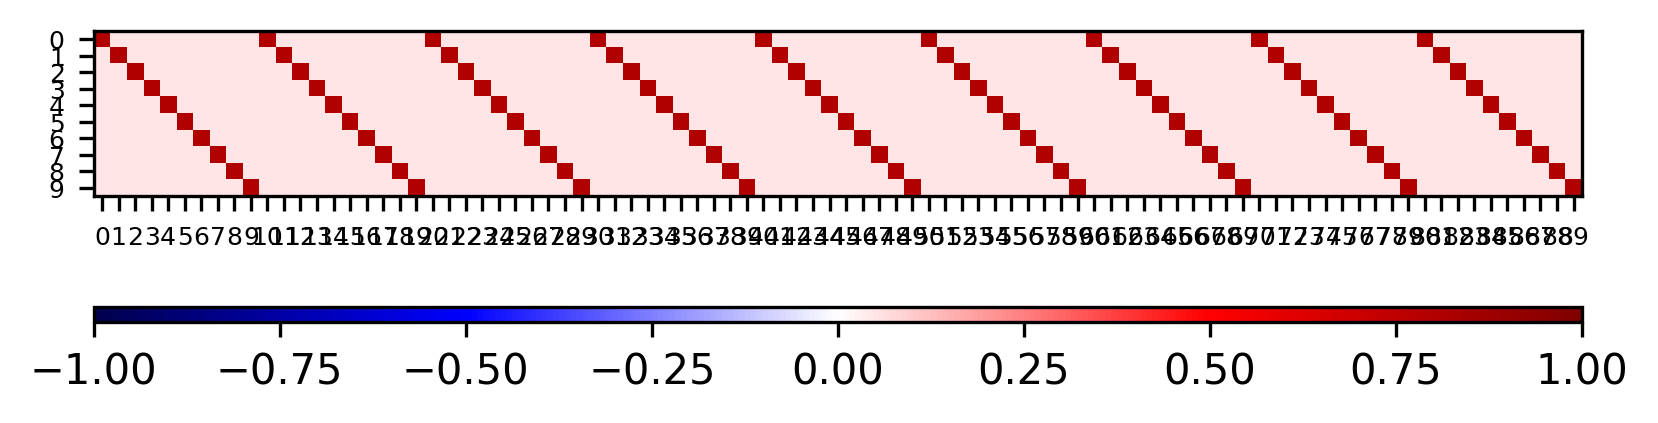

In [25]:
fig, ax = plt.subplots(dpi=300)
ax.imshow(model.G_X_mapping.T, cmap="seismic", vmin=-1, vmax=1)
ax.set_xticks(np.arange(G_dim*9))
ax.set_xticklabels(np.arange(G_dim*9))
ax.set_yticks(np.arange(G_dim))
ax.set_yticklabels(np.arange(G_dim))
ax.tick_params(axis='both', which='major', labelsize=6)
# draw a small horizontal colorbar
cbar = fig.colorbar(ax.get_images()[0], ax=ax, orientation="horizontal", pad=0.1, aspect=100)

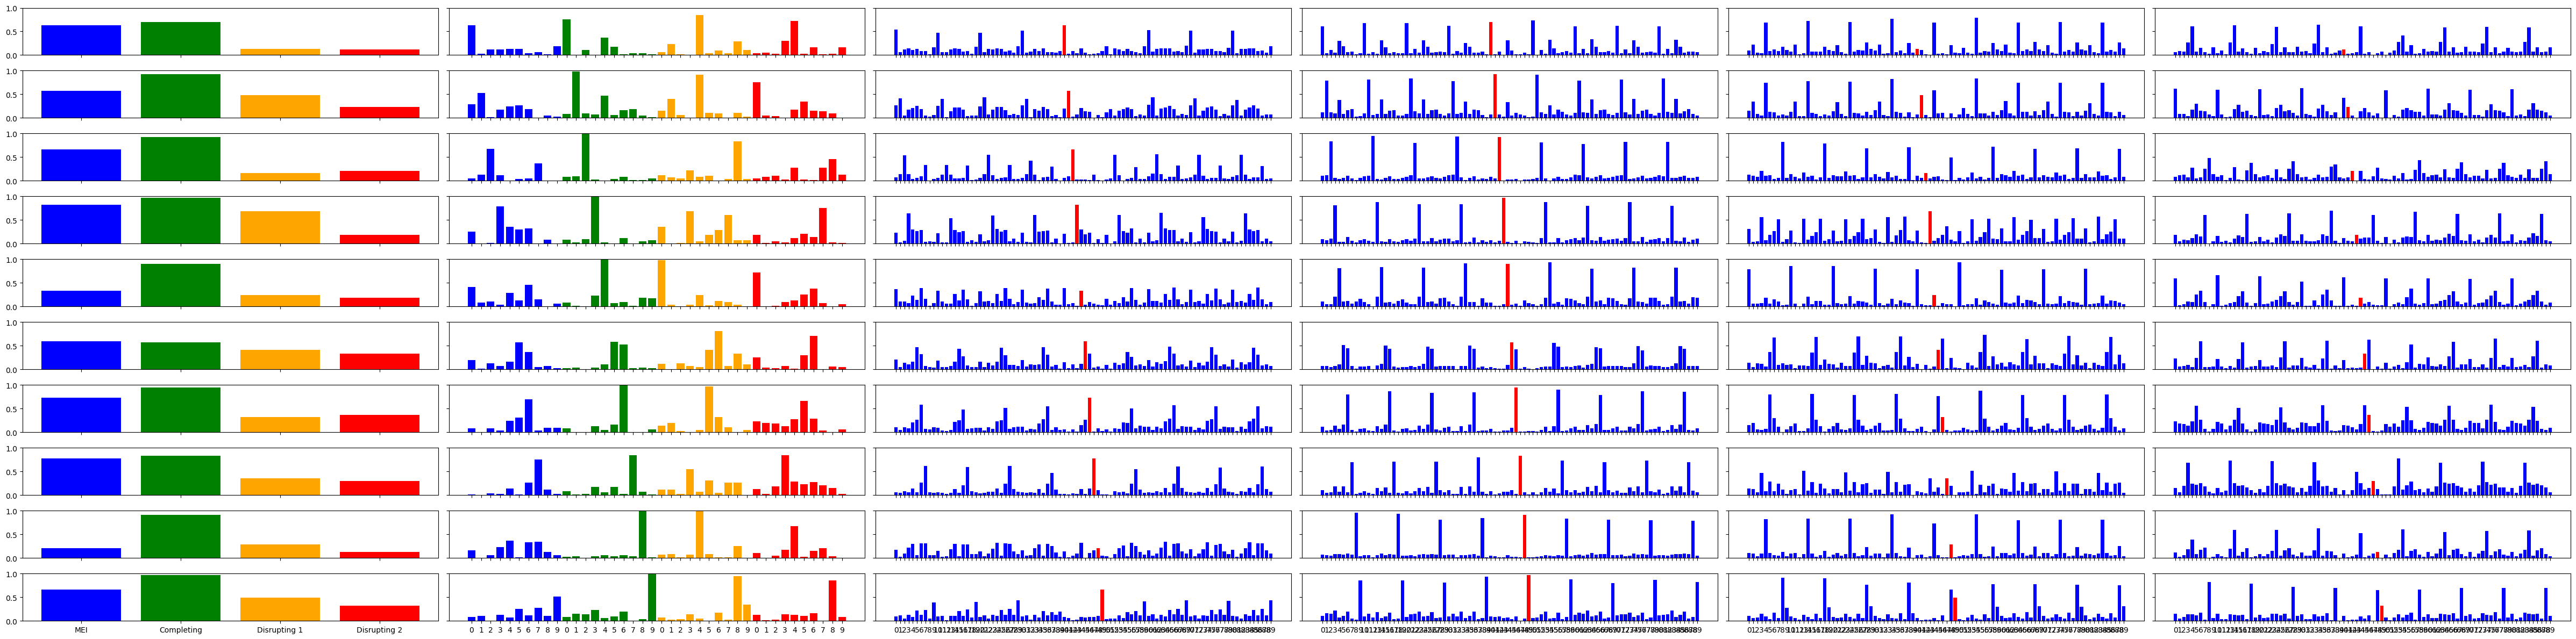

In [26]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

In [27]:
results = [all_idata, G_dim, disrupting_pattern_indices]
import pickle
with open(f"results_{G_dim}_{n_draws}.pkl", "wb") as f:
    pickle.dump(results, f)

In [45]:
with open(f"results_{G_dim}.pkl", "rb") as f:
    results = pickle.load(f)

In [28]:
completing_perc_diff_list

array([ 10.45130641,  60.59027778,  39.80288097,  18.05471125,
       172.91981846,  -4.75396163,  30.04115226,   7.44066709,
       333.88625592,  47.27685325])

In [29]:
disrupting_1_perc_diff_list

array([-79.88915281, -16.14583333, -75.73919636, -16.10942249,
       -27.68532526, -30.19182652, -55.76131687, -54.0731238 ,
        35.07109005, -25.8698941 ])

In [30]:
disrupting_pattern_indices

[4, 4, 8, 7, 0, 6, 5, 3, 4, 8]

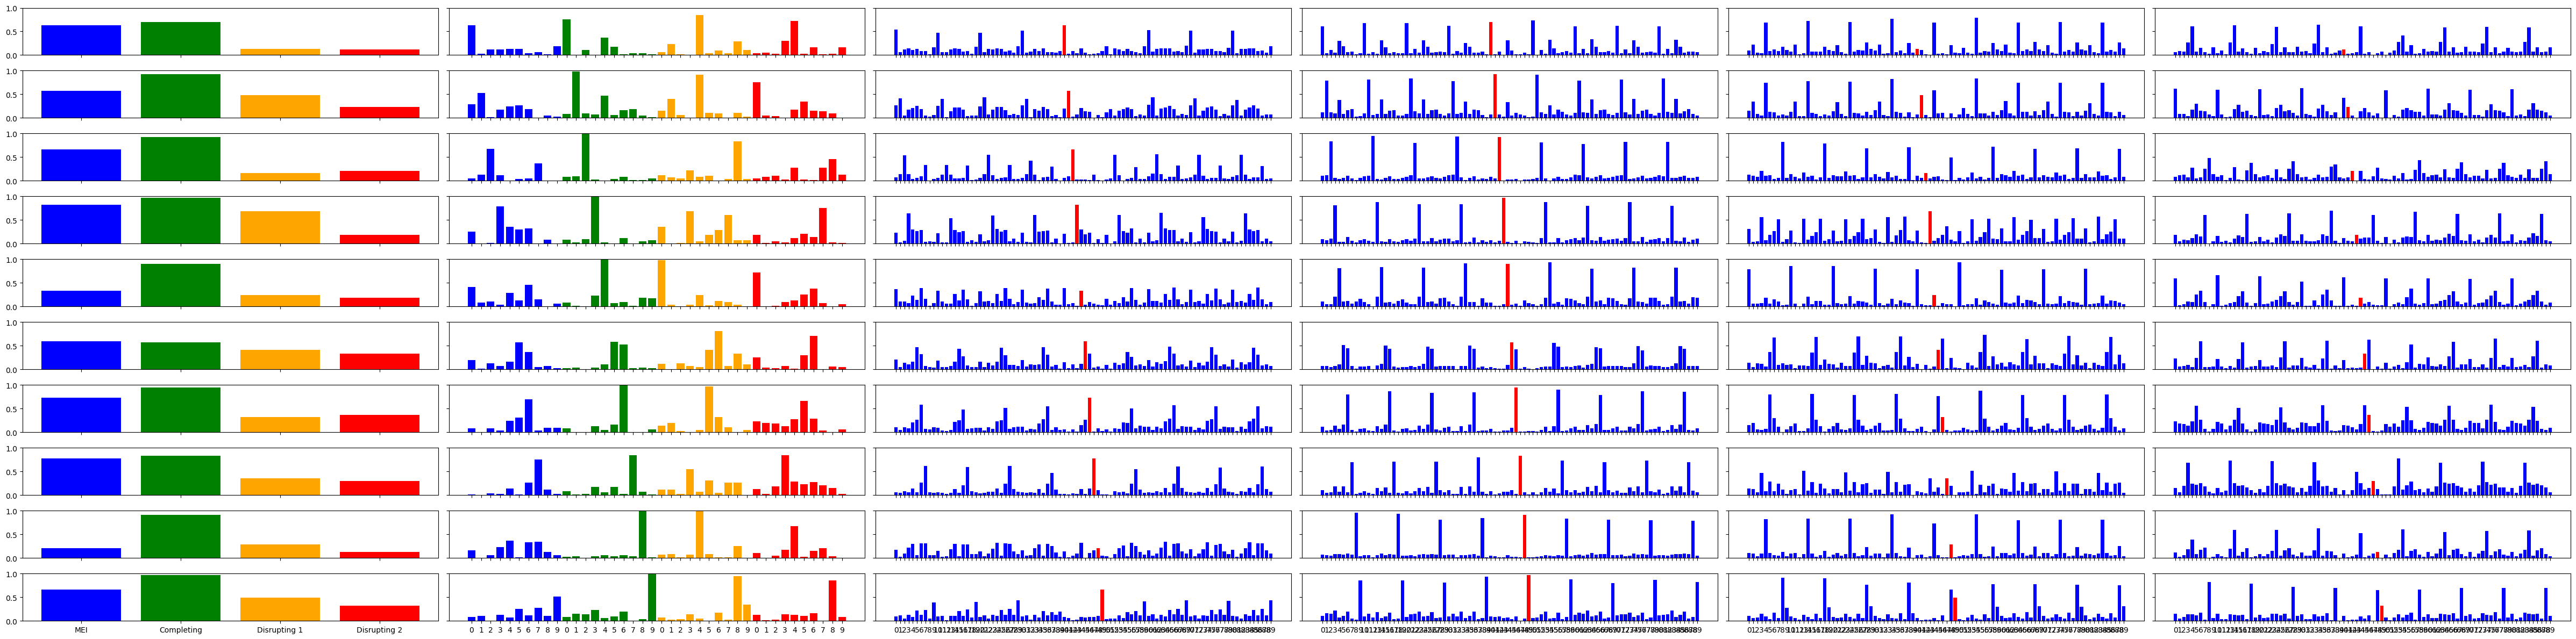

In [31]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

In [32]:
completing_perc_diff_list

array([ 10.45130641,  60.59027778,  39.80288097,  18.05471125,
       172.91981846,  -4.75396163,  30.04115226,   7.44066709,
       333.88625592,  47.27685325])

In [33]:
disrupting_1_perc_diff_list

array([-79.88915281, -16.14583333, -75.73919636, -16.10942249,
       -27.68532526, -30.19182652, -55.76131687, -54.0731238 ,
        35.07109005, -25.8698941 ])

In [34]:
disrupting_2_perc_diff_list

array([-80.76009501, -59.11458333, -68.76421531, -77.87234043,
       -42.51134644, -44.45371143, -49.03978052, -61.8345093 ,
       -39.81042654, -51.36157337])

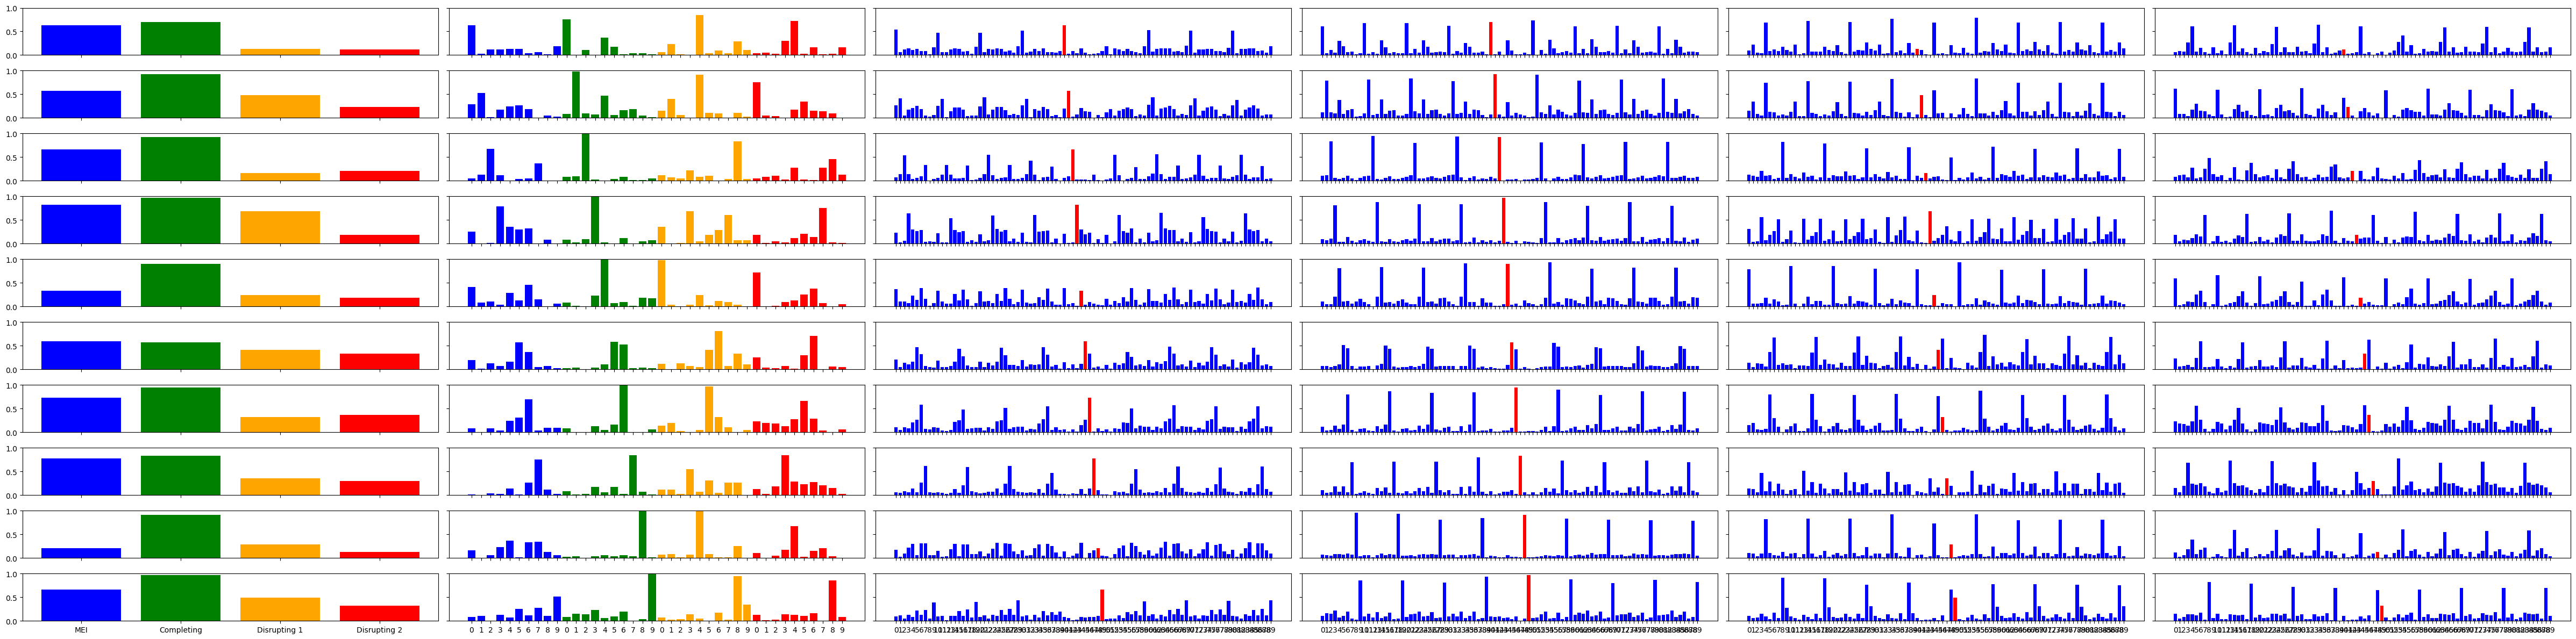

In [35]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

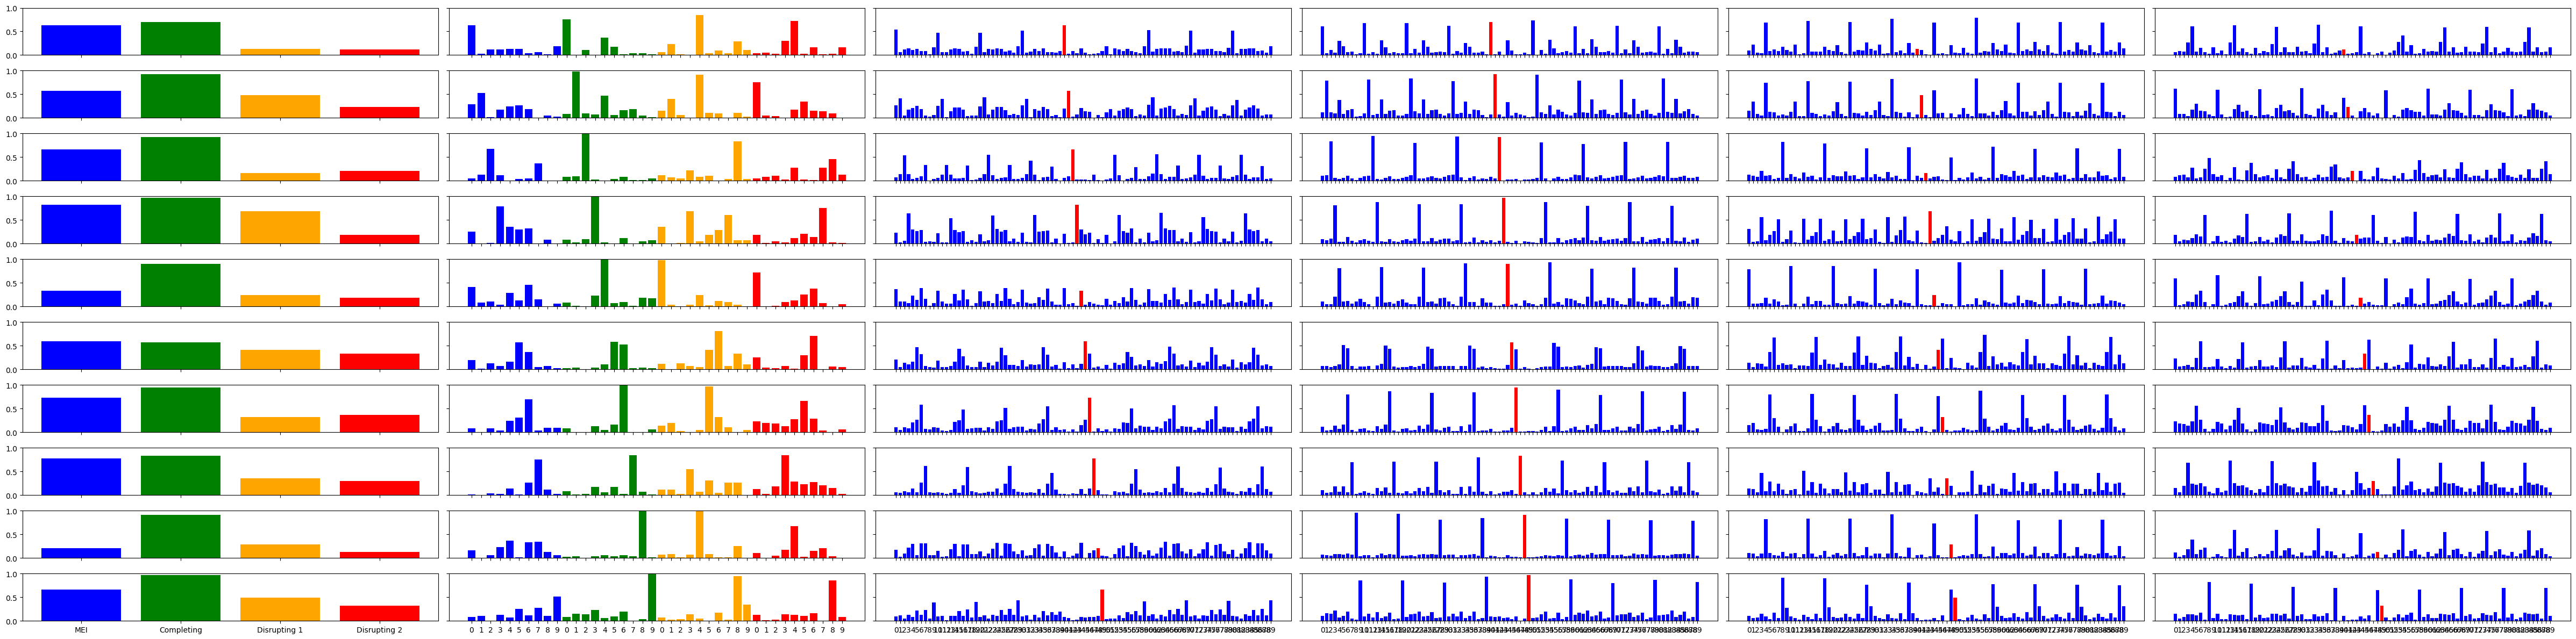

In [36]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

In [37]:
completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list

(array([ 10.45130641,  60.59027778,  39.80288097,  18.05471125,
        172.91981846,  -4.75396163,  30.04115226,   7.44066709,
        333.88625592,  47.27685325]),
 array([-79.88915281, -16.14583333, -75.73919636, -16.10942249,
        -27.68532526, -30.19182652, -55.76131687, -54.0731238 ,
         35.07109005, -25.8698941 ]),
 array([-80.76009501, -59.11458333, -68.76421531, -77.87234043,
        -42.51134644, -44.45371143, -49.03978052, -61.8345093 ,
        -39.81042654, -51.36157337]))

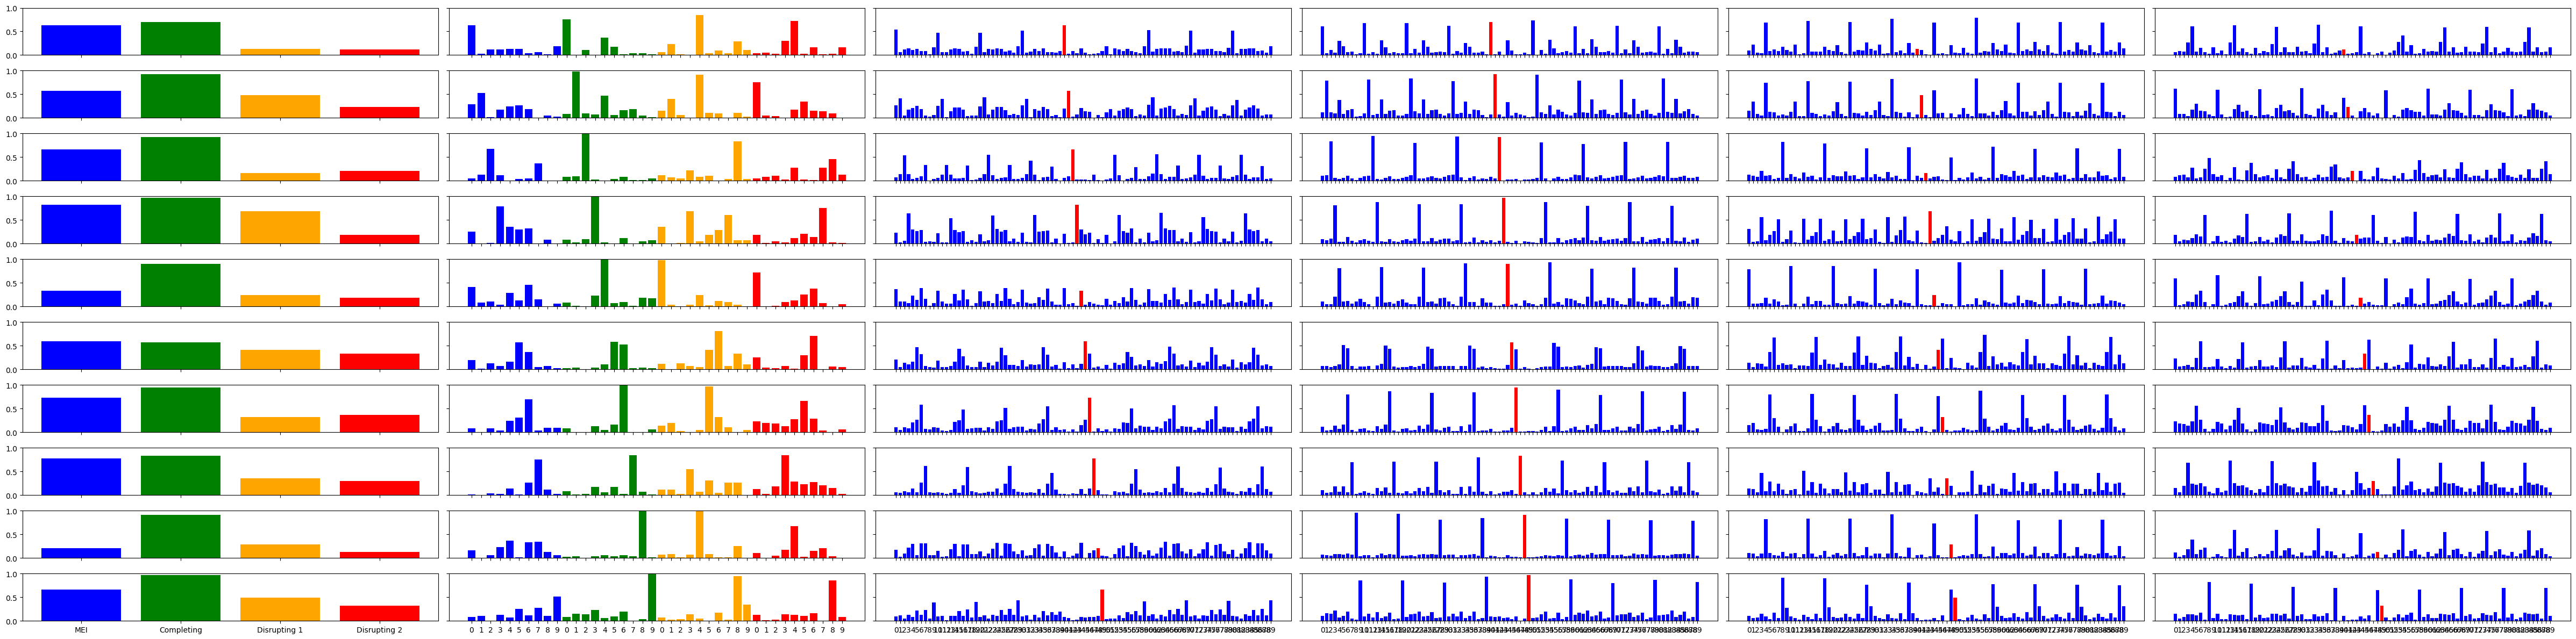

In [38]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

In [39]:
disrupting_1_perc_diff_list

array([-79.88915281, -16.14583333, -75.73919636, -16.10942249,
       -27.68532526, -30.19182652, -55.76131687, -54.0731238 ,
        35.07109005, -25.8698941 ])

In [40]:
completing_perc_diff_list

array([ 10.45130641,  60.59027778,  39.80288097,  18.05471125,
       172.91981846,  -4.75396163,  30.04115226,   7.44066709,
       333.88625592,  47.27685325])

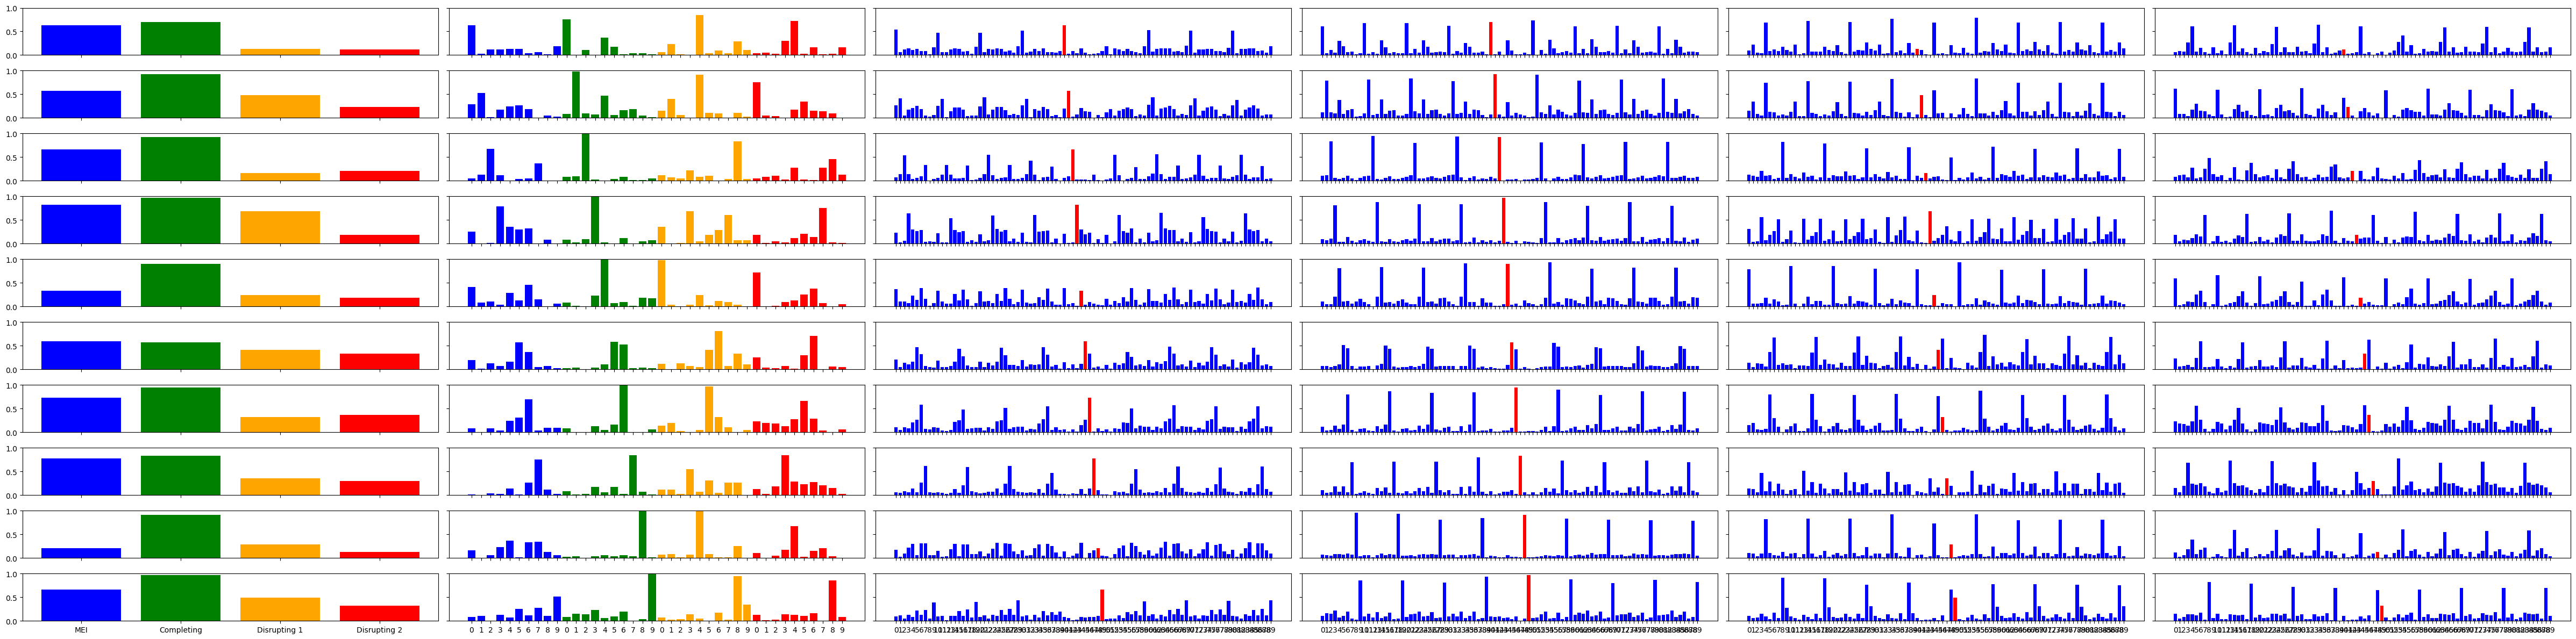

In [41]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

In [42]:
np.all(all_idata[0][0]['posterior']['X'].data == all_idata[1][0]['posterior']['X'].data)

False

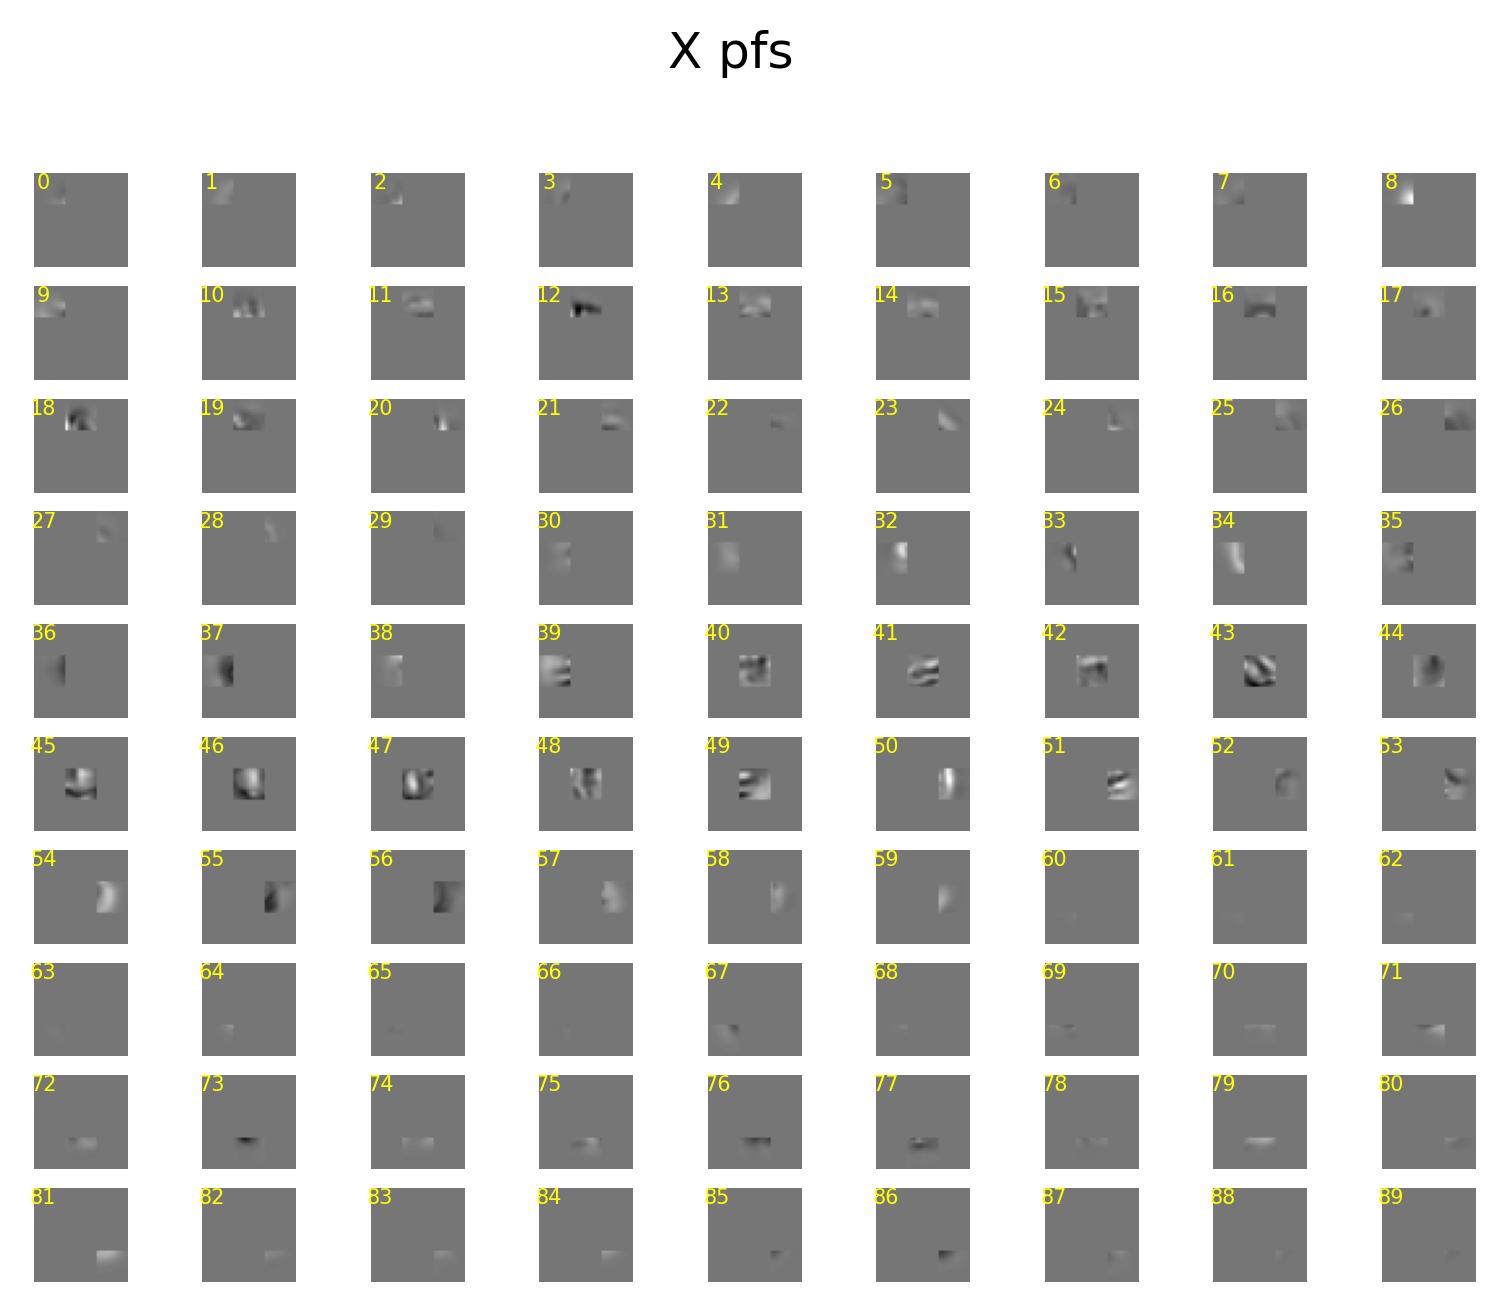

In [43]:
images = model.visualize_learned_X(nrows=x_visual_nrows, ncols=x_visual_ncols)

(-0.5, 35.5, 35.5, -0.5)

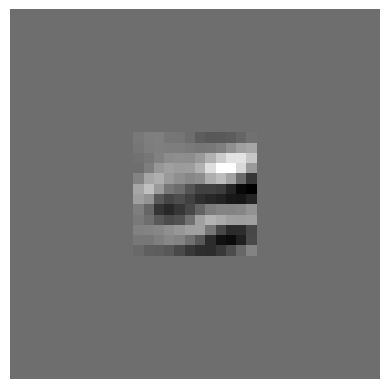

In [44]:
plt.imshow(MEIs[1], cmap="gray")
plt.axis("off")